In [1]:
import os
import warnings
from importlib import metadata


# 检查版本并设置环境变量
warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

try:
    import tensorflow as tf
    import keras
    import bayesflow as bf
except Exception as e:
    raise RuntimeError(
        "Import failed. If you just ran the %pip install cell in VS Code or Colab, please restart the kernel and then rerun this cell. Original error: "
        + repr(e)
    )

expected_versions = {
    "bayesflow": "2.0.9",
    "tensorflow": "2.17.0",
    "keras": "3.13.2",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "scipy": "1.15.3",
    "matplotlib": "3.8.4",
}

for pkg, expected in expected_versions.items():
    current = metadata.version(pkg)
    print(f"{pkg}: {current}")
    if current != expected:
        print(f"  warning: expected {expected}, but found {current}")

np.random.seed(42)
keras.utils.set_random_seed(42)
sns.set_theme(style="whitegrid", context="notebook")

print("BayesFlow backend ready.")

INFO:bayesflow:Using backend 'tensorflow'


bayesflow: 2.0.9
tensorflow: 2.17.0
keras: 3.13.2
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
BayesFlow backend ready.


In [2]:
N_DAYS = 50
TIME_GRID = np.arange(N_DAYS)
I0 = 0.01
R0_INIT = 0.0
S0 = 1.0 - I0 - R0_INIT
OBS_NOISE = 0.02

PRIOR_BOUNDS = {
    "beta": (0.10, 1.00),
    "gamma": (0.05, 0.50),
}

EPS = 1e-6


def to_unconstrained(x, low, high):
    """
    Map x in (low, high) to real line via scaled logit transform.
    """
    u = (x - low) / (high - low)
    u = np.clip(u, EPS, 1.0 - EPS)
    return np.log(u / (1.0 - u))


def from_unconstrained(z, low, high):
    """
    Map real line back to (low, high) via scaled sigmoid transform.
    """
    s = 1.0 / (1.0 + np.exp(-z))
    return low + (high - low) * s


def summarize_posterior_samples(beta_samples, gamma_samples):
    """Return posterior summaries for beta, gamma, and derived R0."""
    beta_samples = np.asarray(beta_samples).reshape(-1)
    gamma_samples = np.asarray(gamma_samples).reshape(-1)
    r0_samples = beta_samples / gamma_samples

    out = {}
    for name, arr in [("beta", beta_samples), ("gamma", gamma_samples), ("R0", r0_samples)]:
        q25, q50, q75 = np.quantile(arr, [0.25, 0.50, 0.75])
        q05, q95 = np.quantile(arr, [0.05, 0.95])

        out[f"{name}_mean"] = float(np.mean(arr))
        out[f"{name}_median"] = float(q50)
        out[f"{name}_std"] = float(np.std(arr, ddof=1))
        out[f"{name}_ci50_low"] = float(q25)
        out[f"{name}_ci50_high"] = float(q75)
        out[f"{name}_ci90_low"] = float(q05)
        out[f"{name}_ci90_high"] = float(q95)
        out[f"{name}_width50"] = float(q75 - q25)
        out[f"{name}_width90"] = float(q95 - q05)

    return out




In [3]:
def sir_rhs(t, y, beta, gamma):
    s, i, r = y
    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i
    return [ds, di, dr]


def solve_sir(beta, gamma, n_days=N_DAYS):
    sol = solve_ivp(
        lambda t, y: sir_rhs(t, y, beta, gamma),
        (0, n_days - 1),
        [S0, I0, R0_INIT],
        t_eval=np.arange(n_days),
        rtol=1e-6,
        atol=1e-8,
    )
    return sol.y.T


def simulate_curve(beta, gamma, rng=None):
    infected = solve_sir(beta, gamma)[:, 1]

    if rng is None:
        noise = np.random.normal(0.0, OBS_NOISE, size=infected.shape)
    else:
        noise = rng.normal(0.0, OBS_NOISE, size=infected.shape)

    obs = infected + noise
    obs = np.clip(obs, 0.0, 1.0)
    return obs[:, None].astype("float32")

def make_training_simulator(train_rng):
    def sim_one():
        beta = train_rng.uniform(*PRIOR_BOUNDS["beta"])
        gamma = train_rng.uniform(*PRIOR_BOUNDS["gamma"])

        z_beta = to_unconstrained(beta, *PRIOR_BOUNDS["beta"])
        z_gamma = to_unconstrained(gamma, *PRIOR_BOUNDS["gamma"])

        return {
            "z_beta": np.array([z_beta], dtype="float32"),
            "z_gamma": np.array([z_gamma], dtype="float32"),
            "obs": simulate_curve(beta, gamma, rng=train_rng),
        }
    return sim_one

def build_workflow(simulator):
    workflow = bf.BasicWorkflow(
        simulator=simulator,
        inference_variables=["z_beta", "z_gamma"],
        summary_variables=["obs"],
        summary_network="time_series_network",
        inference_network="coupling_flow",
    )
    workflow.approximator.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4)
    )
    return workflow


def train_workflow(
    epochs=12,
    batch_size=32,
    num_batches=60,
    seed=42,
):
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)
    train_rng = np.random.default_rng(seed)
    sim_one = make_training_simulator(train_rng)
    simulator = bf.make_simulator(sim_one)
    workflow = build_workflow(simulator)

    history = workflow.approximator.fit(
        simulator=simulator,
        epochs=epochs,
        batch_size=batch_size,
        num_batches=num_batches,
        workers=1,
        verbose=2,
    )
    return workflow, history

In [4]:
def simulate_case_matched(rng=None, beta=None, gamma=None):
    if rng is None:
        rng = np.random.default_rng()

    if beta is None:
        beta = rng.uniform(*PRIOR_BOUNDS["beta"])
    if gamma is None:
        gamma = rng.uniform(*PRIOR_BOUNDS["gamma"])

    obs = simulate_curve(beta, gamma, rng=rng)
    return {
        "true_beta": float(beta),
        "true_gamma": float(gamma),
        "true_R0": float(beta / gamma),
        "obs": obs,
    }


def evaluate_testset(
    workflow,
    case_simulator,
    n_test=50,
    num_posterior_samples=2000,
    seed=123,
    truth_keys=("beta", "gamma", "R0"),
):
    rng = np.random.default_rng(seed)
    rows = []

    for case_id in range(n_test):
        case = case_simulator(rng=rng)
        obs = case["obs"]

        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs[None, ...]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

        row = {"case_id": case_id}
        for k, v in case.items():
            if k != "obs":
                row[k] = v

        row.update(summarize_posterior_samples(beta_samps, gamma_samps))

        # case-level recovery / coverage / errors
        for q in truth_keys:
            true_key = f"true_{q}"
            if true_key in row:
                true_val = row[true_key]

                row[f"{q}_covered50"] = float(
                    row[f"{q}_ci50_low"] <= true_val <= row[f"{q}_ci50_high"]
                )
                row[f"{q}_covered90"] = float(
                    row[f"{q}_ci90_low"] <= true_val <= row[f"{q}_ci90_high"]
                )

                row[f"{q}_err_mean"] = row[f"{q}_mean"] - true_val
                row[f"{q}_err_median"] = row[f"{q}_median"] - true_val
                row[f"{q}_abs_err_median"] = abs(row[f"{q}_median"] - true_val)
                row[f"{q}_sq_err_median"] = (row[f"{q}_median"] - true_val) ** 2

        rows.append(row)

    case_df = pd.DataFrame(rows)

    # Recovery summary
    recovery_rows = []
    for q in truth_keys:
        true_key = f"true_{q}"
        if true_key in case_df.columns:
            recovery_rows.append({
                "quantity": q,
                "bias_mean_est": case_df[f"{q}_err_mean"].mean(),
                "bias_median_est": case_df[f"{q}_err_median"].mean(),
                "MAE_median_est": case_df[f"{q}_abs_err_median"].mean(),
                "RMSE_median_est": np.sqrt(case_df[f"{q}_sq_err_median"].mean()),
                "corr_truth_vs_median": case_df[true_key].corr(case_df[f"{q}_median"]),
                "avg_post_std": case_df[f"{q}_std"].mean(),
            })

    recovery_df = pd.DataFrame(recovery_rows)

    # Coverage summary
    coverage_rows = []
    for q in truth_keys:
        true_key = f"true_{q}"
        if true_key in case_df.columns:
            empirical_50 = case_df[f"{q}_covered50"].mean()
            empirical_90 = case_df[f"{q}_covered90"].mean()

            coverage_rows.append({
                "quantity": q,
                "nominal_50": 0.50,
                "empirical_50": empirical_50,
                "diff_50": empirical_50 - 0.50,
                "nominal_90": 0.90,
                "empirical_90": empirical_90,
                "diff_90": empirical_90 - 0.90,
                "avg_width50": case_df[f"{q}_width50"].mean(),
                "avg_width90": case_df[f"{q}_width90"].mean(),
            })

    coverage_df = pd.DataFrame(coverage_rows)

    return case_df, recovery_df, coverage_df


def extract_curve_features(curve_1d, time_grid=TIME_GRID, early_days=8):
    """
    Extract simple epidemic features from a 1D infected-fraction curve.
    Returns:
        peak_time, peak_height, cumulative_infected, early_growth_slope
    """
    y = np.asarray(curve_1d).reshape(-1)
    t = np.asarray(time_grid).reshape(-1)

    peak_idx = int(np.argmax(y))
    peak_time = float(t[peak_idx])
    peak_height = float(y[peak_idx])

    # area under curve
    cumulative_infected = float(np.trapz(y, t))

    # early growth slope: linear fit on the first early_days points
    k = min(early_days, len(y))
    x_early = t[:k]
    y_early = y[:k]
    slope = float(np.polyfit(x_early, y_early, deg=1)[0])

    return {
        "peak_time": peak_time,
        "peak_height": peak_height,
        "cumulative_infected": cumulative_infected,
        "early_growth_slope": slope,
    }


def evaluate_feature_level_ppc(
    workflow,
    case_simulator,
    predictive_curve_simulator,
    n_test=50,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    feature_names=None,
):
    rng = np.random.default_rng(seed)
    rows = []

    if feature_names is None:
        feature_names = [
            "peak_time",
            "peak_height",
            "cumulative_infected",
            "early_growth_slope",
        ]

    for case_id in range(n_test):
        case = case_simulator(rng=rng)
        obs_full = case["obs"]              # shape: (T, 1)
        obs = obs_full[:, 0]                # shape: (T,)
        obs_feats = extract_curve_features(obs)

        # posterior sampling
        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs_full[None, ...]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

        # choose posterior draws for PPC
        draw_idx = rng.choice(len(beta_samps), size=n_ppc_draws, replace=False)
        beta_draws = beta_samps[draw_idx]
        gamma_draws = gamma_samps[draw_idx]

        # posterior predictive curves
        ppc_feature_rows = {k: [] for k in obs_feats.keys()}

        for b, g in zip(beta_draws, gamma_draws):
            pred_curve = predictive_curve_simulator(float(b), float(g), rng=rng)[:, 0]
            pred_feats = extract_curve_features(pred_curve)

            for feat_name, feat_val in pred_feats.items():
                ppc_feature_rows[feat_name].append(feat_val)

        # summarize feature-level PPC for this case
        for feat_name in feature_names:
            obs_val = obs_feats[feat_name]
            pred_vals = np.asarray(ppc_feature_rows[feat_name], dtype=float)

            q25, q50, q75 = np.quantile(pred_vals, [0.25, 0.50, 0.75])
            q05, q95 = np.quantile(pred_vals, [0.05, 0.95])

            row = {
                "case_id": case_id,
                "feature": feat_name,
                "observed_value": float(obs_val),
                "pred_mean": float(pred_vals.mean()),
                "pred_median": float(q50),
                "pred_std": float(pred_vals.std(ddof=1)),
                "pred_ci50_low": float(q25),
                "pred_ci50_high": float(q75),
                "pred_ci90_low": float(q05),
                "pred_ci90_high": float(q95),
                "pred_width50": float(q75 - q25),
                "pred_width90": float(q95 - q05),
                "covered50": float(q25 <= obs_val <= q75),
                "covered90": float(q05 <= obs_val <= q95),
                "err_mean": float(pred_vals.mean() - obs_val),
                "err_median": float(q50 - obs_val),
                "abs_err_median": float(abs(q50 - obs_val)),
                "sq_err_median": float((q50 - obs_val) ** 2),
            }

            for k, v in case.items():
                if k != "obs":
                    row[k] = v

            rows.append(row)

    feature_case_df = pd.DataFrame(rows)

    # aggregate summary
    summary_rows = []
    for feat_name in feature_names:
        sub = feature_case_df[feature_case_df["feature"] == feat_name].copy()

        empirical_50 = sub["covered50"].mean()
        empirical_90 = sub["covered90"].mean()

        summary_rows.append({
            "feature": feat_name,
            "nominal_50": 0.50,
            "empirical_50": empirical_50,
            "diff_50": empirical_50 - 0.50,
            "nominal_90": 0.90,
            "empirical_90": empirical_90,
            "diff_90": empirical_90 - 0.90,
            "bias_mean_pred": sub["err_mean"].mean(),
            "bias_median_pred": sub["err_median"].mean(),
            "MAE_median_pred": sub["abs_err_median"].mean(),
            "RMSE_median_pred": np.sqrt(sub["sq_err_median"].mean()),
            "avg_pred_std": sub["pred_std"].mean(),
            "avg_width50": sub["pred_width50"].mean(),
            "avg_width90": sub["pred_width90"].mean(),
        })

    feature_summary_df = pd.DataFrame(summary_rows)

    return feature_case_df, feature_summary_df

In [37]:
def extended_extract_curve_features(
    curve_1d,
    time_grid=TIME_GRID,
    early_days=8,
    post_peak_days=8,
    late_start_frac=0.5,
    eps=1e-8,
):
    """
    Extract epidemic features from a 1D infected-fraction curve.

    Returns:
        Basic features:
            peak_time
            peak_height
            cumulative_infected
            early_growth_slope

        Dynamics-sensitive features:
            post_peak_decline_slope
            late_phase_auc
            time_to_half_peak_after_peak
            late_to_early_mean_ratio
    """
    y = np.asarray(curve_1d).reshape(-1).astype(float)
    t = np.asarray(time_grid).reshape(-1).astype(float)

    if len(y) != len(t):
        raise ValueError("curve_1d and time_grid must have the same length.")

    n = len(y)

    # Basic features
    peak_idx = int(np.argmax(y))
    peak_time = float(t[peak_idx])
    peak_height = float(y[peak_idx])

    cumulative_infected = float(np.trapz(y, t))

    # early growth slope: linear fit on the first early_days points
    k_early = min(early_days, n)
    x_early = t[:k_early]
    y_early = y[:k_early]
    if k_early >= 2:
        early_growth_slope = float(np.polyfit(x_early, y_early, deg=1)[0])
    else:
        early_growth_slope = 0.0

    # Dynamics-sensitive features

    # 1) post_peak_decline_slope
    # Fit a line on the next few days after the peak.
    # Typically negative if the curve declines after peak.
    post_start = peak_idx
    post_end = min(peak_idx + post_peak_days + 1, n)
    x_post = t[post_start:post_end]
    y_post = y[post_start:post_end]

    if len(x_post) >= 2:
        post_peak_decline_slope = float(np.polyfit(x_post, y_post, deg=1)[0])
    else:
        post_peak_decline_slope = 0.0

    # 2) late_phase_auc
    # Area under the curve over the late phase (default: second half of window)
    late_start_idx = int(np.floor(late_start_frac * n))
    late_start_idx = min(max(late_start_idx, 0), n - 1)
    late_phase_auc = float(np.trapz(y[late_start_idx:], t[late_start_idx:]))

    # 3) time_to_half_peak_after_peak
    # Time from peak to the first time the curve drops below half the peak.
    half_peak = 0.5 * peak_height
    after_peak = y[peak_idx:]

    below_half_idx = np.where(after_peak <= half_peak)[0]
    if len(below_half_idx) > 0:
        first_below = int(below_half_idx[0])  # relative to peak_idx
        time_to_half_peak_after_peak = float(t[peak_idx + first_below] - t[peak_idx])
    else:
        # right-censored fallback: never reaches half-peak before end of window
        time_to_half_peak_after_peak = float(t[-1] - t[peak_idx])

    # 4) late_to_early_mean_ratio
    # Compare late-phase mean level to early-phase mean level
    early_end_idx = max(1, int(np.floor((1.0 - late_start_frac) * n)))
    early_mean = float(np.mean(y[:early_end_idx]))
    late_mean = float(np.mean(y[late_start_idx:]))
    late_to_early_mean_ratio = float(late_mean / (early_mean + eps))

    return {
        "peak_time": peak_time,
        "peak_height": peak_height,
        "cumulative_infected": cumulative_infected,
        "early_growth_slope": early_growth_slope,
        "post_peak_decline_slope": post_peak_decline_slope,
        "late_phase_auc": late_phase_auc,
        "time_to_half_peak_after_peak": time_to_half_peak_after_peak,
        "late_to_early_mean_ratio": late_to_early_mean_ratio,
    }


def extended_evaluate_feature_level_ppc(
    workflow,
    case_simulator,
    predictive_curve_simulator,
    n_test=50,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    feature_names=None,
    extract_feature_kwargs=None,
):
    rng = np.random.default_rng(seed)
    rows = []

    if feature_names is None:
        feature_names = [
            "peak_time",
            "peak_height",
            "cumulative_infected",
            "early_growth_slope",
            "post_peak_decline_slope",
            "late_phase_auc",
            "time_to_half_peak_after_peak",
            "late_to_early_mean_ratio",
        ]

    if extract_feature_kwargs is None:
        extract_feature_kwargs = {}

    for case_id in range(n_test):
        case = case_simulator(rng=rng)
        obs_full = case["obs"]              # shape: (T, 1)
        obs = obs_full[:, 0]                # shape: (T,)
        obs_feats = extended_extract_curve_features(obs, **extract_feature_kwargs)

        # posterior sampling
        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs_full[None, ...]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

        # choose posterior draws for PPC
        n_available = len(beta_samps)
        n_draws = min(n_ppc_draws, n_available)
        draw_idx = rng.choice(n_available, size=n_draws, replace=False)

        beta_draws = beta_samps[draw_idx]
        gamma_draws = gamma_samps[draw_idx]

        # posterior predictive curves
        ppc_feature_rows = {k: [] for k in feature_names}

        for b, g in zip(beta_draws, gamma_draws):
            pred_curve = predictive_curve_simulator(float(b), float(g), rng=rng)[:, 0]
            pred_feats = extended_extract_curve_features(pred_curve, **extract_feature_kwargs)

            for feat_name in feature_names:
                ppc_feature_rows[feat_name].append(pred_feats[feat_name])

        # summarize feature-level PPC for this case
        for feat_name in feature_names:
            obs_val = float(obs_feats[feat_name])
            pred_vals = np.asarray(ppc_feature_rows[feat_name], dtype=float)

            q25, q50, q75 = np.quantile(pred_vals, [0.25, 0.50, 0.75])
            q05, q95 = np.quantile(pred_vals, [0.05, 0.95])

            row = {
                "case_id": case_id,
                "feature": feat_name,
                "observed_value": obs_val,
                "pred_mean": float(pred_vals.mean()),
                "pred_median": float(q50),
                "pred_std": float(pred_vals.std(ddof=1)) if len(pred_vals) > 1 else 0.0,
                "pred_ci50_low": float(q25),
                "pred_ci50_high": float(q75),
                "pred_ci90_low": float(q05),
                "pred_ci90_high": float(q95),
                "pred_width50": float(q75 - q25),
                "pred_width90": float(q95 - q05),
                "covered50": float(q25 <= obs_val <= q75),
                "covered90": float(q05 <= obs_val <= q95),
                "err_mean": float(pred_vals.mean() - obs_val),
                "err_median": float(q50 - obs_val),
                "abs_err_median": float(abs(q50 - obs_val)),
                "sq_err_median": float((q50 - obs_val) ** 2),
            }

            for k, v in case.items():
                if k != "obs":
                    row[k] = v

            rows.append(row)

    feature_case_df = pd.DataFrame(rows)

    # aggregate summary
    summary_rows = []
    for feat_name in feature_names:
        sub = feature_case_df[feature_case_df["feature"] == feat_name].copy()

        empirical_50 = sub["covered50"].mean()
        empirical_90 = sub["covered90"].mean()

        summary_rows.append({
            "feature": feat_name,
            "nominal_50": 0.50,
            "empirical_50": empirical_50,
            "diff_50": empirical_50 - 0.50,
            "nominal_90": 0.90,
            "empirical_90": empirical_90,
            "diff_90": empirical_90 - 0.90,
            "bias_mean_pred": sub["err_mean"].mean(),
            "bias_median_pred": sub["err_median"].mean(),
            "MAE_median_pred": sub["abs_err_median"].mean(),
            "RMSE_median_pred": np.sqrt(sub["sq_err_median"].mean()),
            "avg_pred_std": sub["pred_std"].mean(),
            "avg_width50": sub["pred_width50"].mean(),
            "avg_width90": sub["pred_width90"].mean(),
        })

    feature_summary_df = pd.DataFrame(summary_rows)

    return feature_case_df, feature_summary_df

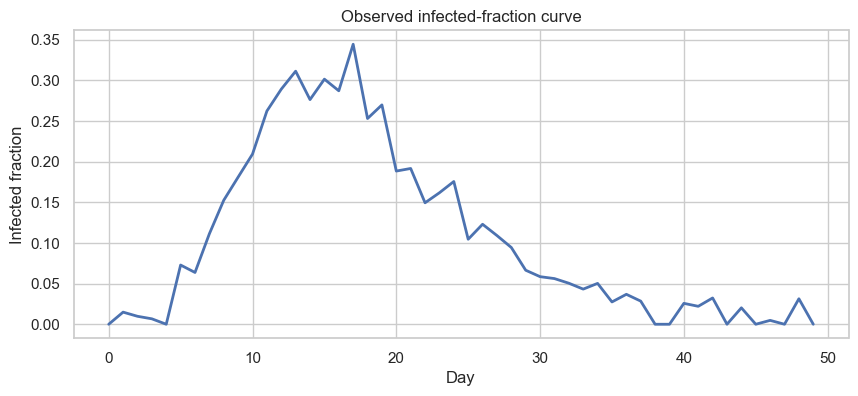

True beta: 0.55
True gamma: 0.18
True R0: 3.056


In [5]:
true_beta = 0.55
true_gamma = 0.18
true_r0 = true_beta / true_gamma
single_case_rng = np.random.default_rng(2025)
observed_curve = simulate_curve(true_beta, true_gamma, rng=single_case_rng)

plt.figure(figsize=(10, 4))
plt.plot(TIME_GRID, observed_curve[:, 0], lw=2)
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Observed infected-fraction curve")
plt.show()

print("True beta:", true_beta)
print("True gamma:", true_gamma)
print("True R0:", round(true_r0, 3))

First, to respect the bounded support of epidemiological parameters, we infer unconstrained transformed variables and map posterior samples back to the original parameter space via an inverse sigmoid transform.

图1展示了 E0 matched baseline 中的一个single case观测序列。我们首先使用 SIR 动力学在给定真值参数 `beta = 0.55`、`gamma = 0.18` 下生成 latent infected-fraction trajectory，然后加入标准差为 `0.02` 的 Gaussian observation noise，并将结果裁剪到合法区间 `[0, 1]`，从而得到最终的 observed infected-fraction curve。由于 `R0 = beta / gamma = 3.056 > 1`，感染比例在早期快速上升，并在中期达到峰值，之后随着易感者耗竭和恢复累积而逐渐下降。图中的局部波动主要来自观测噪声，因此该曲线是 noisy replicated observation。

INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 11s - 182ms/step - loss: 2.4911
Epoch 2/12
60/60 - 3s - 51ms/step - loss: 1.4776
Epoch 3/12
60/60 - 3s - 57ms/step - loss: 0.7338
Epoch 4/12
60/60 - 4s - 61ms/step - loss: 0.0469
Epoch 5/12
60/60 - 3s - 58ms/step - loss: -1.9847e-02
Epoch 6/12
60/60 - 3s - 58ms/step - loss: -4.1947e-01
Epoch 7/12
60/60 - 3s - 55ms/step - loss: -5.5080e-01
Epoch 8/12
60/60 - 4s - 59ms/step - loss: -4.7803e-01
Epoch 9/12
60/60 - 3s - 56ms/step - loss: -8.6912e-01
Epoch 10/12
60/60 - 3s - 54ms/step - loss: -7.8531e-01
Epoch 11/12
60/60 - 3s - 54ms/step - loss: -9.1669e-01
Epoch 12/12
60/60 - 3s - 54ms/step - loss: -8.4954e-01


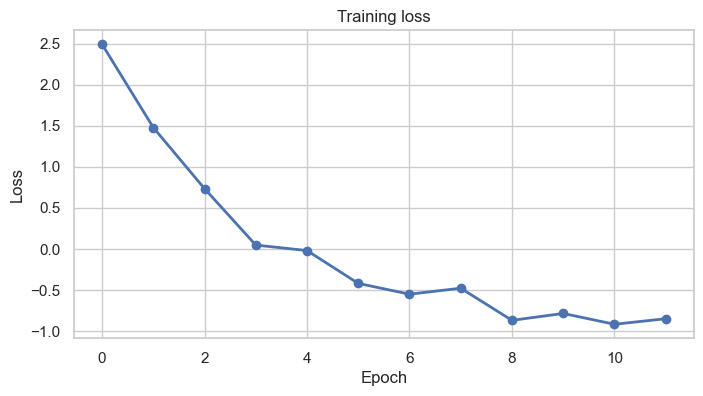

In [6]:
workflow_E0, history_E0 = train_workflow(seed=42)

plt.figure(figsize=(8, 4))
plt.plot(history_E0.history["loss"], marker="o", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

图2展示了 BayesFlow posterior estimator 在 matched SIR-to-SIR baseline 下的训练 loss。训练过程中，模型通过在线模拟不断生成新的 `(obs, z_beta, z_gamma)` 样本，并学习从 noisy infected-fraction time series 到参数后验的 amortized inference rule。我们可以看到，loss 在前几个 epoch 内快速下降，说明模型较快捕捉到了观测曲线形状与潜在参数之间的主要对应关系；之后 loss 继续下降并在后期进入轻微波动的平台区间。总的来说，loss 曲线没有出现发散或持续回升，说明我们的训练过程稳定，并为后续的 posterior recovery、coverage 和 PPC 结果提供了基础。

In [7]:
samples = workflow_E0.sample(
    num_samples=4000,
    conditions={"obs": observed_curve[None, ...]},
    split=True,
    batch_size=1,
)

z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

posterior_df = pd.DataFrame({
    "beta": beta_samps,
    "gamma": gamma_samps,
})
posterior_df["R0"] = posterior_df["beta"] / posterior_df["gamma"]

summary_table = posterior_df[["beta", "gamma", "R0"]].describe(percentiles=[0.05, 0.5, 0.95]).T
summary_table = summary_table[["mean", "std", "5%", "50%", "95%"]]
summary_table

Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.13batch/s]
INFO:bayesflow:Sampling completed in 0.29 seconds.


,mean,std,5%,50%,95%
beta,0.538153,0.012792,0.516809,0.538200,0.559293
gamma,0.180431,0.005996,0.170929,0.180224,0.190554
R0,2.985118,0.101628,2.818640,2.983993,3.157492


给定观测曲线后，我们从训练好的 BayesFlow posterior 中抽取 4000 个后验样本，并将 transformed variables `z_beta` 和 `z_gamma` 反变换回原始参数空间。然后，我们逐样本计算 derived quantity `R0 = beta / gamma`，从而得到 `beta`、`gamma` 和 `R0` 的联合后验汇总。结果表明，`beta` 的 posterior 中心约为 `0.538`，`gamma` 的 posterior 中心约为 `0.180`，而 `R0` 的 posterior 中心约为 `2.984`。三者的真值均落在 90% posterior interval 内，说明该 matched baseline 在单案例上能够较好恢复参数及其派生流行病学量。特别是，`R0` 的后验明显大于 1，表明模型正确识别了该观测序列对应于一个处于扩张阶段的 epidemic regime。

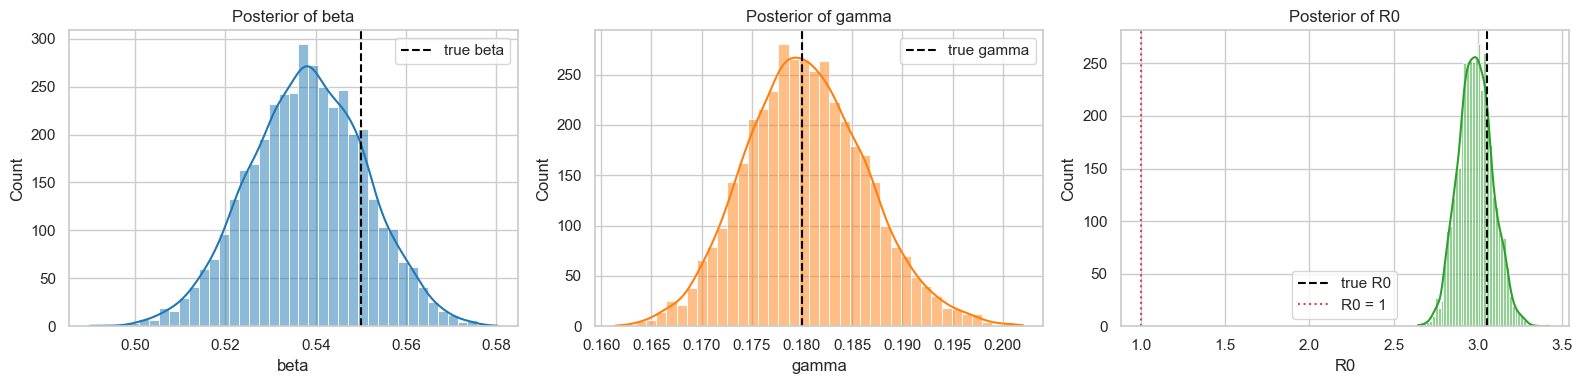

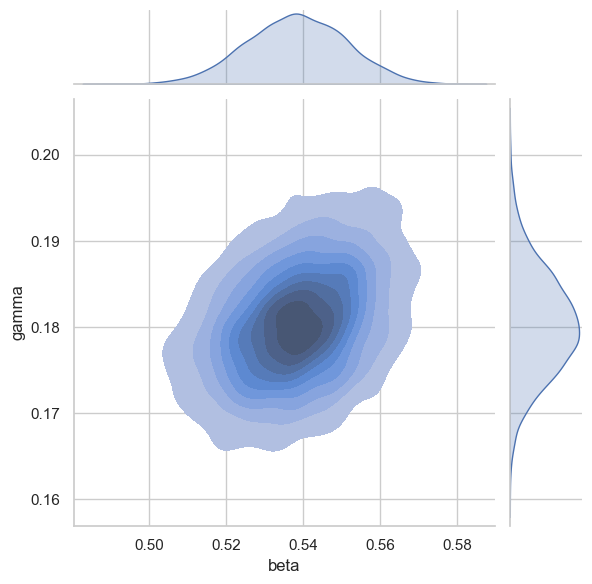

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(posterior_df["beta"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(true_beta, color="black", linestyle="--", label="true beta")
axes[0].set_title("Posterior of beta")
axes[0].legend()

sns.histplot(posterior_df["gamma"], kde=True, ax=axes[1], color="#ff7f0e")
axes[1].axvline(true_gamma, color="black", linestyle="--", label="true gamma")
axes[1].set_title("Posterior of gamma")
axes[1].legend()

sns.histplot(posterior_df["R0"], kde=True, ax=axes[2], color="#2ca02c")
axes[2].axvline(true_r0, color="black", linestyle="--", label="true R0")
axes[2].axvline(1.0, color="#c44e52", linestyle=":", label="R0 = 1")
axes[2].set_title("Posterior of R0")
axes[2].legend()

plt.tight_layout()
plt.show()

sns.jointplot(data=posterior_df, x="beta", y="gamma", kind="kde", fill=True)
plt.show()

这几张图展示了单案例下 `beta`、`gamma` 和 derived quantity `R0` 的边缘后验分布，以及 `beta–gamma` 的联合后验结构。我们可以看到，三个边缘后验均呈现单峰且较为平滑的分布形状，说明在 matched SIR-to-SIR baseline 下，给定该观测曲线后，模型得到的是稳定且集中的后验，而不是多峰或异常长尾的近似。`beta` 的后验中心略低于真值 `0.55`，但真值仍位于高密度区域内；`gamma` 的后验中心则与真值 `0.18` 非常接近。`R0` 的后验几乎完全位于 `1` 以上，表明模型明确支持该案例处于扩张型 epidemic regime，而不是衰退阶段。联合后验图进一步显示 `beta` 与 `gamma` 存在一定正相关，说明不同的传播率与恢复率组合可以在一定程度上共同解释相似的观测曲线形状。

In [9]:
r0_ci = np.quantile(posterior_df["R0"], [0.05, 0.5, 0.95])
prob_r0_gt_1 = float((posterior_df["R0"] > 1.0).mean())

print(f"True R0: {true_r0:.3f}")
print(f"Posterior median R0: {r0_ci[1]:.3f}")
print(f"Posterior 90% interval for R0: [{r0_ci[0]:.3f}, {r0_ci[2]:.3f}]")
print(f"Posterior probability R0 > 1: {prob_r0_gt_1:.4f}")

True R0: 3.056
Posterior median R0: 2.984
Posterior 90% interval for R0: [2.819, 3.157]
Posterior probability R0 > 1: 1.0000


为了进一步将参数后验转化为流行病学解释，我们基于 posterior samples 逐样本计算 `R0 = beta / gamma`，并报告其中位数、90% posterior interval，以及 `P(R0 > 1)`。结果表明，该案例的 posterior median `R0` 约为 `2.984`，90% posterior interval 为 `[2.819, 3.157]`，真实值 `3.056` 落在该区间内。更重要的是，posterior probability `P(R0 > 1)` 为 `1.0000`，说明在该观测曲线下，模型几乎确定地支持一个 supercritical epidemic regime。这与观测曲线在早期表现出的明显增长趋势一致，也表明 matched baseline 不仅能够恢复参数数值, but also at providing the correct epidemiological interpretation through a derived posterior quantity.

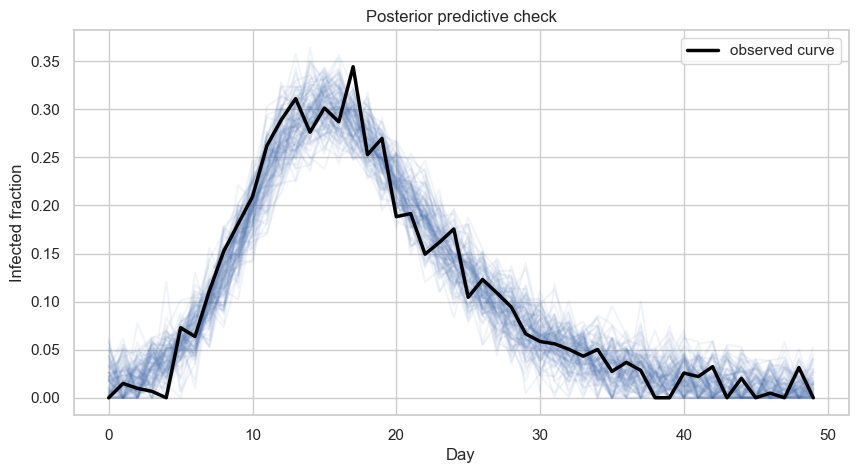

In [10]:
n_ppc = 100
single_ppc_rng = np.random.default_rng(2024)
draw_ids = single_ppc_rng.choice(len(posterior_df), size=n_ppc, replace=False)
ppc_draws = posterior_df.iloc[draw_ids][["beta", "gamma"]].to_numpy()
ppc_curves = np.stack(
    [simulate_curve(beta, gamma, rng=single_ppc_rng)[:, 0] for beta, gamma in ppc_draws],
    axis=0,
)

plt.figure(figsize=(10, 5))
for curve in ppc_curves:
    plt.plot(TIME_GRID, curve, color="#4c72b0", alpha=0.08)
plt.plot(TIME_GRID, observed_curve[:, 0], color="black", lw=2.5, label="observed curve")
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Posterior predictive check")
plt.legend()
plt.show()

这张图图展示的是single case下的 posterior predictive check。我们首先从单案例 posterior 中抽取 100 组 `(beta, gamma)` 样本，然后在每组参数下重新生成 noisy infected-fraction observation，并将这些 replicated curves 与原始观测曲线叠加比较。可以看到，posterior predictive curves 整体复现了观测曲线的主要结构，包括早期增长、中期峰值和后期衰减，同时在峰值位置、峰值高度和尾部衰减幅度上都与观测曲线保持一致。虽然单条 replicated curve 不会逐点贴合观测曲线，但黑色观测曲线总体位于 posterior predictive cloud 的高密度区域内，说明当前 posterior 在数据空间中也是合理的。需要注意的是，这里的 PPC 比较对象是带噪的 replicated observations，而不是无噪声 latent epidemic trajectories，因此图中的局部抖动和尾部贴近 0 的现象都属于 observation model 的自然结果。

Sampling: 100%|██████████| 1/1 [00:00<00:00, 10.57batch/s]
INFO:bayesflow:Sampling completed in 0.32 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.98batch/s]
INFO:bayesflow:Sampling completed in 0.25 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.09batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.81batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.92batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.87batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.27batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.96batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.00batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 


Per-case summary head:


,case_id,true_beta,true_gamma,true_R0,beta_mean,beta_median,beta_std,beta_ci50_low,beta_ci50_high,beta_ci90_low,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.261041,0.337961,0.772401,0.149366,0.117901,0.077242,0.103887,0.159933,0.100163,...,-0.134880,-0.169698,0.169698,0.028797,1.0,1.0,0.167262,0.084806,0.084806,0.007192
1,1,0.708075,0.309730,2.286106,0.698493,0.698791,0.018755,0.686153,0.711835,0.667156,...,0.016218,0.016005,0.016005,0.000256,0.0,0.0,-0.141426,-0.143886,0.143886,0.020703
2,2,0.404338,0.350867,1.152396,0.385337,0.381784,0.106043,0.306842,0.461634,0.215229,...,0.018983,0.036228,0.036228,0.001312,1.0,1.0,-0.086940,-0.091420,0.091420,0.008358
3,3,0.803229,0.214378,3.746785,0.799761,0.800627,0.024142,0.783306,0.816561,0.758571,...,-0.002577,-0.002736,0.002736,0.000007,1.0,1.0,0.034306,0.023821,0.023821,0.000567
4,4,0.543643,0.336812,1.614083,0.481789,0.481110,0.021385,0.467068,0.495480,0.446983,...,-0.027308,-0.027301,0.027301,0.000745,0.0,1.0,-0.054664,-0.057593,0.057593,0.003317



Recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,-0.0106,-0.0188,0.0400,0.0670,0.9687,0.0533
1,gamma,-0.0042,-0.0003,0.0370,0.0702,0.8458,0.0435
2,R0,-0.0395,-0.0535,0.1428,0.1984,0.9978,0.2525



Coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.52,0.02,0.9,0.89,-0.01,0.0689,0.1701
1,gamma,0.5,0.54,0.04,0.9,0.91,0.01,0.0685,0.1367
2,R0,0.5,0.61,0.11,0.9,0.96,0.06,0.3399,0.8199


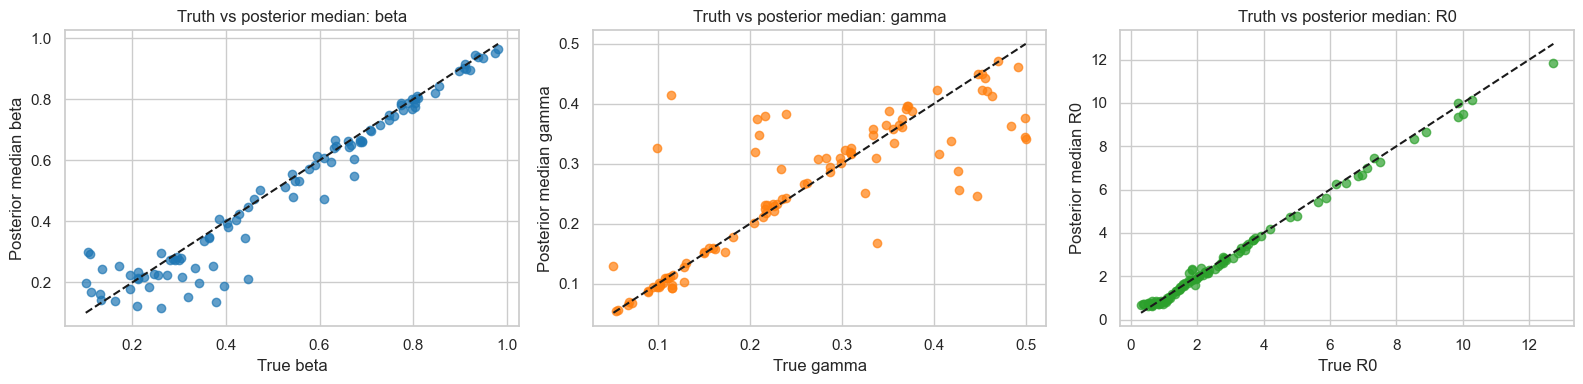

Saved:
  outputs_baseline/E0_matched_case_level.csv
  outputs_baseline/E0_matched_recovery_summary.csv
  outputs_baseline/E0_matched_coverage_summary.csv


In [11]:
case_df, recovery_df, coverage_df = evaluate_testset(
    workflow=workflow_E0,
    case_simulator=simulate_case_matched,
    n_test=100,
    num_posterior_samples=2000,
    seed=2026,
)

print("\nPer-case summary head:")
display(case_df.head())

print("\nRecovery summary:")
display(recovery_df.round(4))

print("\nCoverage summary:")
display(coverage_df.round(4))


# Truth-vs-median scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, q, color in zip(
    axes,
    ["beta", "gamma", "R0"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
):
    x = case_df[f"true_{q}"]
    y = case_df[f"{q}_median"]

    ax.scatter(x, y, alpha=0.7, color=color)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
    ax.set_xlabel(f"True {q}")
    ax.set_ylabel(f"Posterior median {q}")
    ax.set_title(f"Truth vs posterior median: {q}")

plt.tight_layout()
plt.show()


# save E0 outputs
os.makedirs("outputs_baseline", exist_ok=True)
case_df.to_csv("outputs_baseline/E0_matched_case_level.csv", index=False)
recovery_df.to_csv("outputs_baseline/E0_matched_recovery_summary.csv", index=False)
coverage_df.to_csv("outputs_baseline/E0_matched_coverage_summary.csv", index=False)

print("Saved:")
print("  outputs_baseline/E0_matched_case_level.csv")
print("  outputs_baseline/E0_matched_recovery_summary.csv")
print("  outputs_baseline/E0_matched_coverage_summary.csv")

为了评估 matched baseline 在一批测试案例上的参数恢复能力，我们对 100 个由同一 SIR 生成机制产生的 test cases 分别进行 posterior sampling，并将 posterior median 与对应真值进行散点对比。结果显示，`beta` 的 posterior median 与真值整体高度一致，大多数点贴近对角线，说明传播率总体恢复良好，但在较低 `beta` 区域散布稍大；`gamma` 也表现出明显的正对应关系，但偏离对角线的程度更大，表明恢复率在全局上比传播率更难识别；相比之下，derived quantity `R0` 的 truth-vs-median 关系最为紧密，几乎沿对角线排列，说明 epidemic regime 的强弱能够被模型非常稳定地恢复。总体来看，这组图表明在 E0 matched setting 下，BayesFlow posterior 不仅在单案例上合理，而且在 batch level 上也具备良好的参数恢复能力。

Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.96batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.78batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.22batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.22batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.17batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.29batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.16batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 11.63batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 23.70batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 


Feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.59,0.09,0.9,0.94,0.04,0.8991,0.4200,6.4900,10.2494,7.2644,11.4000,22.5825
1,peak_height,0.5,0.59,0.09,0.9,0.95,0.05,-0.0031,-0.0051,0.0126,0.0167,0.0211,0.0256,0.0643
2,cumulative_infected,0.5,0.70,0.20,0.9,0.97,0.07,0.0750,0.0220,0.1730,0.2915,0.4452,0.4952,1.3230
3,early_growth_slope,0.5,0.53,0.03,0.9,0.93,0.03,-0.0013,-0.0013,0.0023,0.0030,0.0034,0.0045,0.0109



Feature-level PPC case head:


,case_id,feature,observed_value,pred_mean,pred_median,pred_std,pred_ci50_low,pred_ci50_high,pred_ci90_low,pred_ci90_high,...,pred_width90,covered50,covered90,err_mean,err_median,abs_err_median,sq_err_median,true_beta,true_gamma,true_R0
0,0,peak_time,47.0000,26.4500,26.0000,15.7483,13.0000,41.2500,2.0000,48.0500,...,46.0500,0.0,1.0,-20.5500,-21.0000,21.0000,441.0000,0.2610,0.3380,0.7724
1,0,peak_height,0.0632,0.0592,0.0554,0.0189,0.0466,0.0706,0.0352,0.0901,...,0.0549,1.0,1.0,-0.0040,-0.0078,0.0078,0.0001,0.2610,0.3380,0.7724
2,0,cumulative_infected,0.6088,0.7844,0.6012,0.4766,0.4533,1.0189,0.3508,1.6572,...,1.3064,1.0,1.0,0.1756,-0.0077,0.0077,0.0001,0.2610,0.3380,0.7724
3,0,early_growth_slope,-0.0024,-0.0004,-0.0004,0.0023,-0.0020,0.0013,-0.0043,0.0036,...,0.0079,0.0,1.0,0.0020,0.0020,0.0020,0.0000,0.2610,0.3380,0.7724
4,1,peak_time,26.0000,29.7100,29.5000,13.4505,20.7500,42.2500,6.9500,48.0000,...,41.0500,1.0,1.0,3.7100,3.5000,3.5000,12.2500,0.2339,0.1921,1.2174


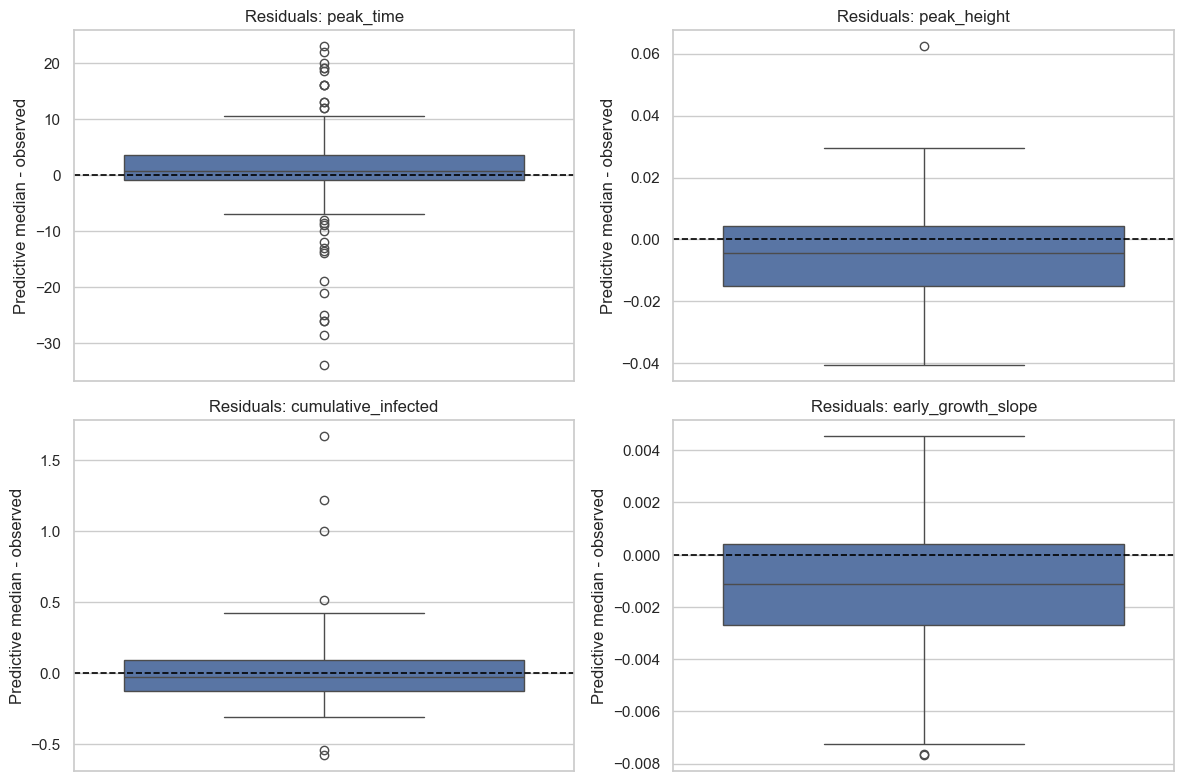

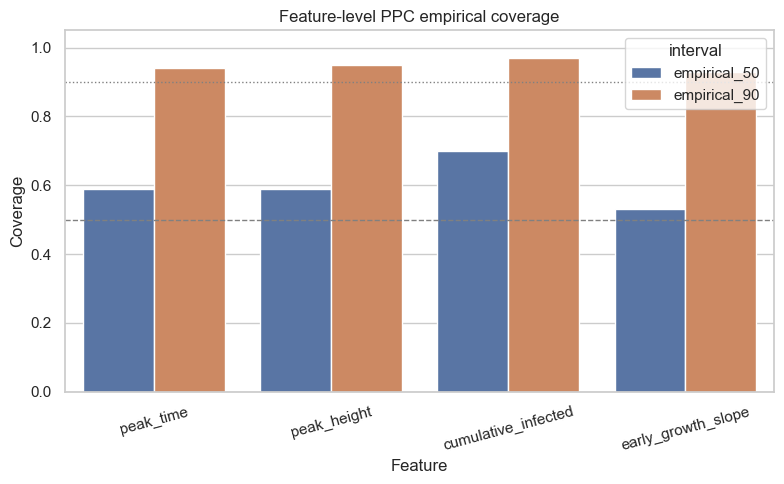

Saved:
  outputs_baseline/E0_matched_ppc_feature_case_level.csv
  outputs_baseline/E0_matched_ppc_feature_summary.csv


In [12]:
# Run feature-level PPC evaluation
feature_case_df, feature_summary_df = evaluate_feature_level_ppc(
    workflow=workflow_E0,
    case_simulator=simulate_case_matched,
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
)

print("\nFeature-level PPC summary:")
display(feature_summary_df.round(4))

print("\nFeature-level PPC case head:")
display(feature_case_df.head().round(4))


# Residual visualization by feature
# residual = posterior predictive median - observed feature
plot_df = feature_case_df.copy()
plot_df["residual"] = plot_df["err_median"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_order = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
]

for ax, feat in zip(axes, feature_order):
    sub = plot_df[plot_df["feature"] == feat].copy()
    sns.boxplot(data=sub, y="residual", ax=ax)
    ax.axhline(0.0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"Residuals: {feat}")
    ax.set_xlabel("")
    ax.set_ylabel("Predictive median - observed")

plt.tight_layout()
plt.show()


# Coverage visualization by feature
cov_plot_df = feature_summary_df.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)

plt.figure(figsize=(8, 5))
sns.barplot(data=cov_plot_df, x="feature", y="coverage", hue="interval")
plt.axhline(0.50, color="gray", linestyle="--", lw=1.0)
plt.axhline(0.90, color="gray", linestyle=":", lw=1.0)
plt.title("Feature-level PPC empirical coverage")
plt.xlabel("Feature")
plt.ylabel("Coverage")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# save E0 feature-level PPC outputs
feature_case_df.to_csv("outputs_baseline/E0_matched_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv("outputs_baseline/E0_matched_ppc_feature_summary.csv", index=False)

print("Saved:")
print("  outputs_baseline/E0_matched_ppc_feature_case_level.csv")
print("  outputs_baseline/E0_matched_ppc_feature_summary.csv")

为了从特征层面检查 posterior predictive adequacy，我们将每条 observed curve 和 posterior predictive replicated curve 分别压缩为四个 summary features：`peak_time`、`peak_height`、`cumulative_infected` 和 `early_growth_slope`。随后，我们在 100 个 matched test cases 上比较 observed features 与 posterior predictive feature distributions，并报告残差分布与 empirical coverage。结果显示，四个 feature 的 90% predictive coverage 均接近或略高于 nominal 0.9，说明 matched baseline 在 feature space 中总体具有良好的 posterior predictive adequacy。50% coverage 也整体接近 nominal 0.5，但多数 feature 略偏高，表明 predictive intervals 略保守。其中，`peak_height` 和 `early_growth_slope` 的残差分布较集中，说明模型能够较稳定地复现峰值高度和早期增长行为；`cumulative_infected` 的 coverage 偏高，说明整体感染负担的不确定性区间稍宽；`peak_time` 的残差分布最分散，这是因为该特征通过 noisy curve 上的 `argmax` 定义，对局部噪声特别敏感，因此应被视为支持性但相对不稳健的 feature-level diagnostic。

## Overall E0 baseline figure

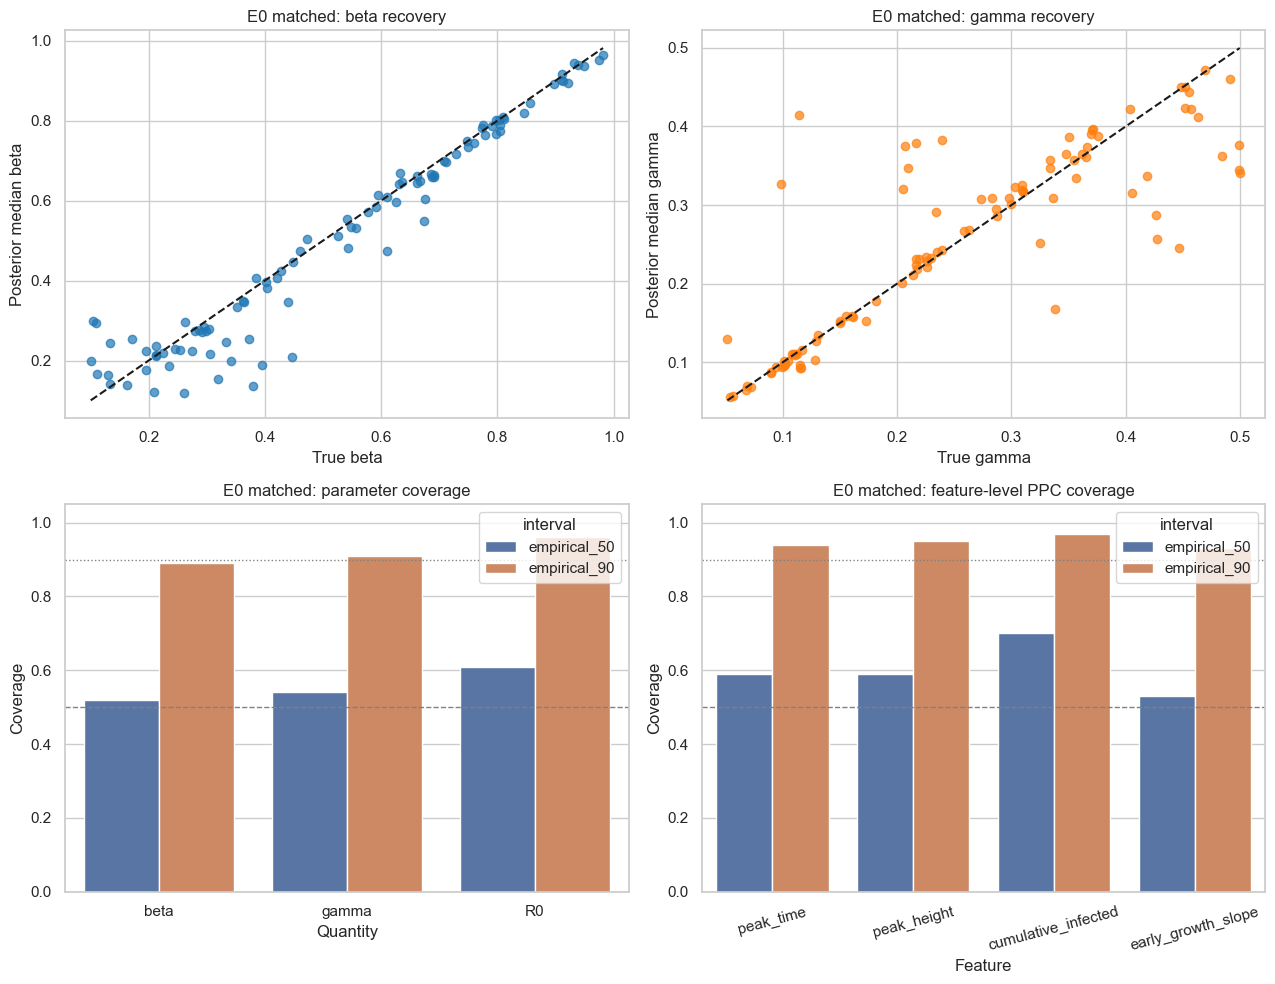

Saved:
  outputs_baseline/E0_matched_overall_baseline_figure.png


In [13]:
# 1) parameter recovery panels use beta / gamma scatter
# 2) parameter coverage panel uses empirical vs nominal
# 3) feature-level PPC coverage panel uses empirical vs nominal

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: beta recovery
ax = axes[0, 0]
x = case_df["true_beta"]
y = case_df["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True beta")
ax.set_ylabel("Posterior median beta")
ax.set_title("E0 matched: beta recovery")

# Panel B: gamma recovery
ax = axes[0, 1]
x = case_df["true_gamma"]
y = case_df["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title("E0 matched: gamma recovery")

# Panel C: parameter empirical vs nominal coverage
ax = axes[1, 0]
param_cov_plot = coverage_df.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title("E0 matched: parameter coverage")

# Panel D: feature-level PPC empirical vs nominal coverage
ax = axes[1, 1]
feat_cov_plot = feature_summary_df.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title("E0 matched: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

fig.savefig("outputs_baseline/E0_matched_overall_baseline_figure.png", dpi=200, bbox_inches="tight")
print("Saved:")
print("  outputs_baseline/E0_matched_overall_baseline_figure.png")

左上图和右上图分别展示 `beta` 与 `gamma` 的 batch-level truth-vs-posterior-median recovery，我们可以看到 `beta` 的恢复整体较稳定，大多数样本贴近对角线，而 `gamma` 的散布更大，表明恢复率在 matched setting 下也比传播率更难识别。左下图展示参数层的 empirical interval coverage，相比 nominal 0.5 与 0.9，`beta`、`gamma` 和 `R0` 的覆盖总体合理，仅存在轻微偏差：`beta` 略有 under-coverage，`R0` 则略显保守。右下图展示 feature-level PPC coverage，结果表明 `peak_time`、`peak_height`、`cumulative_infected` 和 `early_growth_slope` 的 posterior predictive coverage 均接近或略高于 nominal，说明 matched baseline 在 feature space 中也具有良好的 predictive adequacy。整体而言，这张图表明 E0 不仅能恢复参数真值，还能给出大体合理的不确定性区间，并在曲线特征层面复现观测行为，因此E0可以作为后续misspecification 实验的可靠参照baseline。

# E2: dynamical misspecification, test-only time-varying beta(t) misspecification

1. 保留 E0 的训练代码和训练结果不变
2. 新写一个“时变 β(t) 的测试 simulator”，只用于生成 test cases
3. 把 E0 的 matched evaluation 函数复用到 misspecified test set 上
4. 输出和 E0 同结构的表格与图，然后和 E0 对比解释退化

In [20]:
E2_CHANGE_DAY_RANGE = (10, 30)

E2_SEVERITY_CONFIG = {
    "mild":   {"kappa_low": 0.85, "kappa_high": 1.00},
    "medium": {"kappa_low": 0.60, "kappa_high": 0.85},
    "strong": {"kappa_low": 0.30, "kappa_high": 0.60},
}


def beta_t_piecewise(time_grid, beta0, tau, kappa):
    """
    Piecewise-constant time-varying beta schedule:
        beta(t) = beta0             for t < tau
                = kappa * beta0     for t >= tau

    Args:
        time_grid: array-like of times
        beta0: baseline beta before change
        tau: change point
        kappa: multiplicative factor after change

    Returns:
        beta_t: np.ndarray with same length as time_grid
    """
    t = np.asarray(time_grid)
    beta_t = np.where(t < tau, beta0, kappa * beta0).astype(float)
    return beta_t


def sir_rhs_timevarying(t, y, beta0, gamma, tau, kappa):
    """
    SIR RHS with piecewise time-varying beta(t).
    """
    s, i, r = y
    beta_t = beta0 if t < tau else kappa * beta0
    ds = -beta_t * s * i
    di = beta_t * s * i - gamma * i
    dr = gamma * i
    return [ds, di, dr]


def solve_sir_timevarying_beta(beta0, gamma, tau, kappa, n_days=N_DAYS):
    """
    Solve SIR with piecewise time-varying beta(t).
    Returns array of shape (n_days, 3): [S, I, R].
    """
    sol = solve_ivp(
        lambda t, y: sir_rhs_timevarying(t, y, beta0, gamma, tau, kappa),
        (0, n_days - 1),
        [S0, I0, R0_INIT],
        t_eval=np.arange(n_days),
        rtol=1e-6,
        atol=1e-8,
    )
    return sol.y.T


def simulate_curve_timevarying_beta(beta0, gamma, tau, kappa, rng=None):
    """
    Simulate observed infected-fraction curve under time-varying beta(t),
    then add Gaussian observation noise and clip to [0, 1].
    Returns shape (T, 1), same format as simulate_curve(...).
    """
    infected = solve_sir_timevarying_beta(beta0, gamma, tau, kappa)[:, 1]

    if rng is None:
        noise = np.random.normal(0.0, OBS_NOISE, size=infected.shape)
    else:
        noise = rng.normal(0.0, OBS_NOISE, size=infected.shape)

    obs = infected + noise
    obs = np.clip(obs, 0.0, 1.0)
    return obs[:, None].astype("float32")


def compute_beta_ref_mean(beta0, tau, kappa, n_days=N_DAYS):
    """
    Reference scalar beta used for recovery / coverage in E2.

    We define:
        beta_ref = average beta(t) over the observation window.
    """
    beta_path = beta_t_piecewise(np.arange(n_days), beta0, tau, kappa)
    return float(beta_path.mean())


def simulate_case_E2(rng=None, severity="strong", beta0=None, gamma=None, tau=None, kappa=None):
    """
    Generate one E2 test case:
      - latent data-generating process uses time-varying beta(t)
      - output still includes scalar reference truth for evaluation:
            true_beta  := average beta(t) over time window
            true_gamma := true constant gamma
            true_R0    := true_beta_ref / gamma

    severity in {"mild", "medium", "strong"}
    """
    if rng is None:
        rng = np.random.default_rng()

    if severity not in E2_SEVERITY_CONFIG:
        raise ValueError(f"Unknown severity='{severity}'. Choose from {list(E2_SEVERITY_CONFIG.keys())}")

    cfg = E2_SEVERITY_CONFIG[severity]

    if beta0 is None:
        beta0 = rng.uniform(*PRIOR_BOUNDS["beta"])
    if gamma is None:
        gamma = rng.uniform(*PRIOR_BOUNDS["gamma"])
    if tau is None:
        tau = int(rng.integers(E2_CHANGE_DAY_RANGE[0], E2_CHANGE_DAY_RANGE[1] + 1))
    if kappa is None:
        kappa = rng.uniform(cfg["kappa_low"], cfg["kappa_high"])

    obs = simulate_curve_timevarying_beta(beta0, gamma, tau, kappa, rng=rng)

    beta_ref = compute_beta_ref_mean(beta0, tau, kappa, n_days=N_DAYS)

    return {
        "true_beta": float(beta_ref),             # reference scalar beta for evaluation
        "true_gamma": float(gamma),
        "true_R0": float(beta_ref / gamma),
        "beta0": float(beta0),                    # underlying pre-change beta
        "gamma": float(gamma),
        "tau": int(tau),
        "kappa": float(kappa),
        "severity": severity,
        "obs": obs,
    }


def run_E2_evaluation(
    workflow,
    severity="strong",
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2027,
):
    """
    Run E2 evaluation using the already-trained constant-beta workflow.
    Posterior predictive simulator remains simulate_curve(...) because the
    inferred model is still the matched constant-beta SIR.
    """
    def case_simulator(rng=None):
        return simulate_case_E2(rng=rng, severity=severity)

    case_df_E2, recovery_df_E2, coverage_df_E2 = evaluate_testset(
        workflow=workflow,
        case_simulator=case_simulator,
        n_test=n_test,
        num_posterior_samples=num_posterior_samples,
        seed=seed,
    )

    feature_case_df_E2, feature_summary_df_E2 = evaluate_feature_level_ppc(
        workflow=workflow,
        case_simulator=case_simulator,
        predictive_curve_simulator=simulate_curve,   # still constant-beta predictive model
        n_test=n_test,
        num_posterior_samples=min(1000, num_posterior_samples),
        n_ppc_draws=n_ppc_draws,
        seed=seed,
    )

    return (
        case_df_E2,
        recovery_df_E2,
        coverage_df_E2,
        feature_case_df_E2,
        feature_summary_df_E2,
    )




1. 证明错配来自 transmission dynamics，而不是 observation noise
2. 错配强度可以通过 kappa 连续控制
3. 单个 strong case 是否显示出明显的 transmission shift
4. 如果观测曲线表面上仍然合理，那么这是一个“真实但不显眼”的 misspecification setting

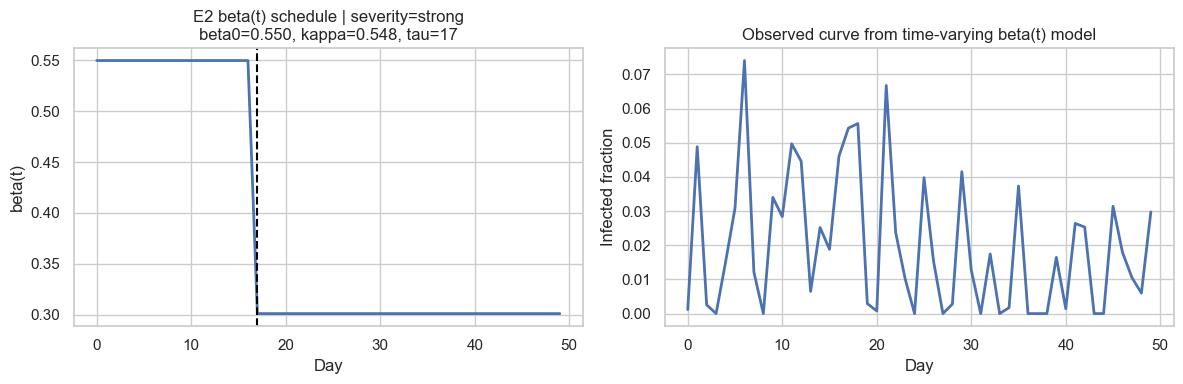

Example E2 case:
  severity   : strong
  beta0      : 0.5497
  kappa      : 0.5480
  tau        : 17
  beta_ref   : 0.3857
  gamma      : 0.4305
  R0_ref     : 0.8958


In [21]:
# Example: visualize one E2 case

example_rng = np.random.default_rng(3030)
example_case_E2 = simulate_case_E2(rng=example_rng, severity="strong")

example_obs_E2 = example_case_E2["obs"][:, 0]
example_beta_path = beta_t_piecewise(
    TIME_GRID,
    beta0=example_case_E2["beta0"],
    tau=example_case_E2["tau"],
    kappa=example_case_E2["kappa"],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(TIME_GRID, example_beta_path, lw=2)
axes[0].axvline(example_case_E2["tau"], color="black", linestyle="--", lw=1.5)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("beta(t)")
axes[0].set_title(
    f"E2 beta(t) schedule | severity={example_case_E2['severity']}\n"
    f"beta0={example_case_E2['beta0']:.3f}, kappa={example_case_E2['kappa']:.3f}, tau={example_case_E2['tau']}"
)

axes[1].plot(TIME_GRID, example_obs_E2, lw=2)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Infected fraction")
axes[1].set_title("Observed curve from time-varying beta(t) model")

plt.tight_layout()
plt.show()

print("Example E2 case:")
print(f"  severity   : {example_case_E2['severity']}")
print(f"  beta0      : {example_case_E2['beta0']:.4f}")
print(f"  kappa      : {example_case_E2['kappa']:.4f}")
print(f"  tau        : {example_case_E2['tau']}")
print(f"  beta_ref   : {example_case_E2['true_beta']:.4f}")
print(f"  gamma      : {example_case_E2['true_gamma']:.4f}")
print(f"  R0_ref     : {example_case_E2['true_R0']:.4f}")



To instantiate E2, we keep the inference model fixed to the matched constant-β SIR setup used in E0, but generate test observations from a piecewise time-varying transmission process. Specifically, β(t) equals β0 before a change point τ and drops to κβ0 afterwards. The severity of misspecification is controlled by κ, with smaller values corresponding to stronger deviations from the constant-β assumption. This figure illustrates a representative strong case, where β(t) decreases from approximately 0.55 to 0.30 after day 17. Although the underlying transmission mechanism is clearly non-stationary, the resulting observed trajectory still appears visually plausible as an epidemic time series, highlighting why this form of misspecification may not be obvious from the observations alone. For evaluation within the constant-β parameter space, we define a reference scalar β as the time-average of β(t) over the observation window.

## 当 misspecification 还比较弱时，后验已经开始出现可检测的退化，但这种退化仍然是“轻度、结构化的”，而不是全面崩塌：

Sampling: 100%|██████████| 1/1 [00:00<00:00, 13.75batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.23batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.39batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.68batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.93batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.84batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.19batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.23batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.28batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 


E2 (mild) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.101553,0.223647,0.454077,0.107205,0.223647,15,0.924685,mild,0.223715,...,0.081885,0.094291,0.094291,8.890836e-03,0.0,1.0,0.339172,0.299749,0.299749,0.089849
1,1,0.680205,0.142269,4.781116,0.702721,0.142269,11,0.958922,mild,0.689871,...,-0.001180,-0.001325,0.001325,1.756755e-06,1.0,1.0,0.117109,0.113079,0.113079,0.012787
2,2,0.505587,0.100655,5.022946,0.565901,0.100655,11,0.863358,mild,0.553534,...,-0.000830,-0.000836,0.000836,6.985500e-07,0.0,0.0,0.534814,0.523226,0.523226,0.273766
3,3,0.125957,0.458047,0.274986,0.132926,0.458047,20,0.912616,mild,0.208289,...,-0.166361,-0.162660,0.162660,2.645819e-02,0.0,0.0,0.521219,0.454373,0.454373,0.206455
4,4,0.750525,0.338086,2.219919,0.797830,0.338086,22,0.894120,mild,0.790657,...,-0.004891,-0.005555,0.005555,3.086174e-05,0.0,0.0,0.155341,0.149023,0.149023,0.022208



E2 (mild) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0219,0.0117,0.0504,0.0681,0.9699,0.0566
1,gamma,-0.0118,-0.0074,0.0392,0.0669,0.8633,0.0466
2,R0,0.1097,0.0947,0.1725,0.2368,0.9962,0.2349



E2 (mild) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.37,-0.13,0.9,0.73,-0.17,0.0702,0.1770
1,gamma,0.5,0.47,-0.03,0.9,0.95,0.05,0.0748,0.1455
2,R0,0.5,0.49,-0.01,0.9,0.87,-0.03,0.3147,0.7591



E2 (mild) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.60,0.10,0.9,0.93,0.03,-0.6394,-1.1050,5.1150,8.5655,6.4919,10.1650,19.7040
1,peak_height,0.5,0.60,0.10,0.9,0.96,0.06,0.0016,0.0003,0.0128,0.0204,0.0217,0.0270,0.0664
2,cumulative_infected,0.5,0.74,0.24,0.9,0.99,0.09,0.1122,0.0777,0.2030,0.4182,0.4277,0.4745,1.2630
3,early_growth_slope,0.5,0.42,-0.08,0.9,0.94,0.04,-0.0011,-0.0010,0.0026,0.0032,0.0032,0.0042,0.0104


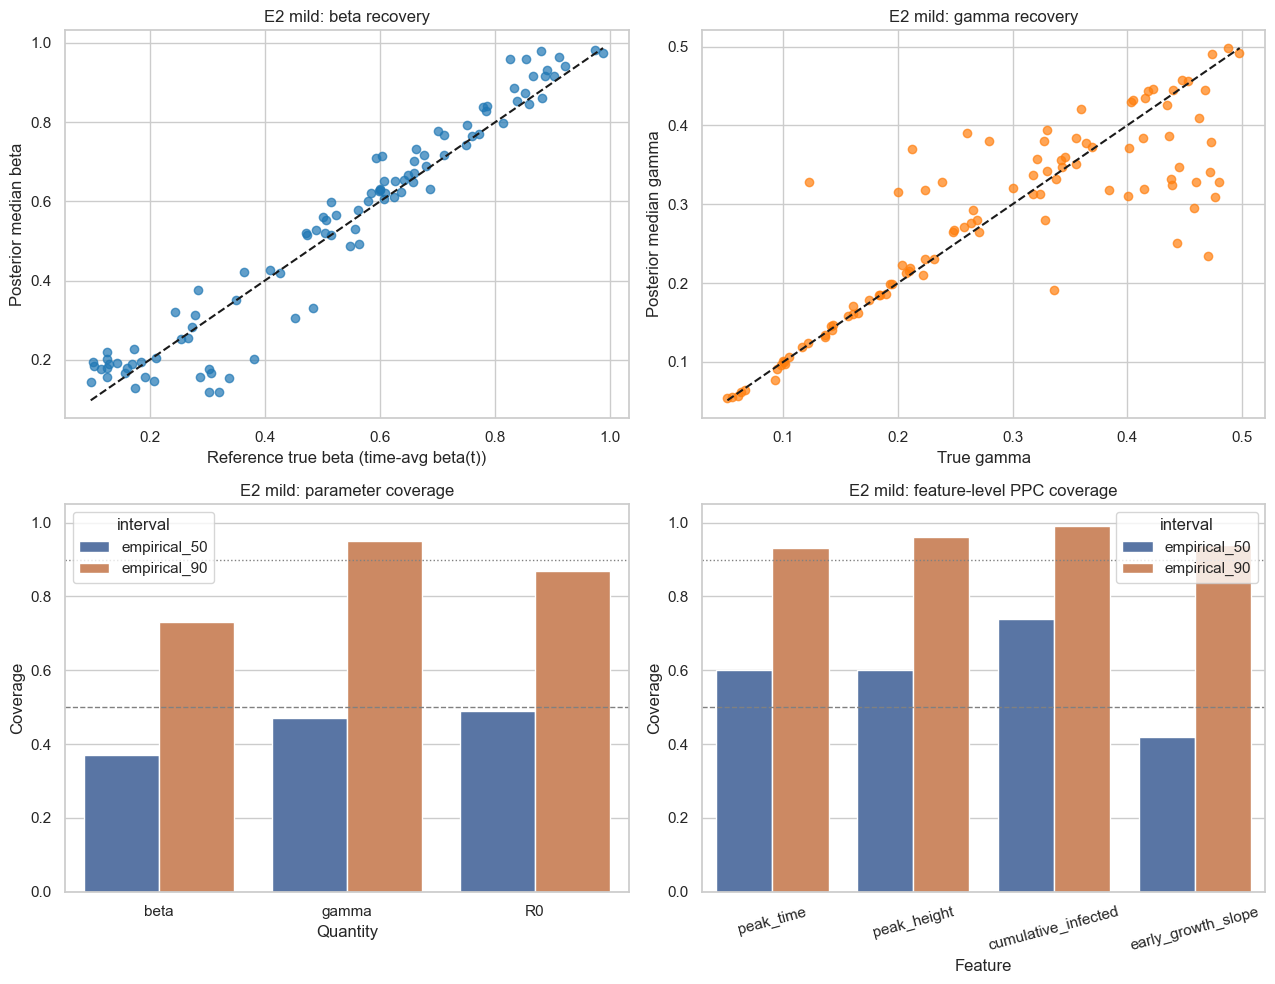

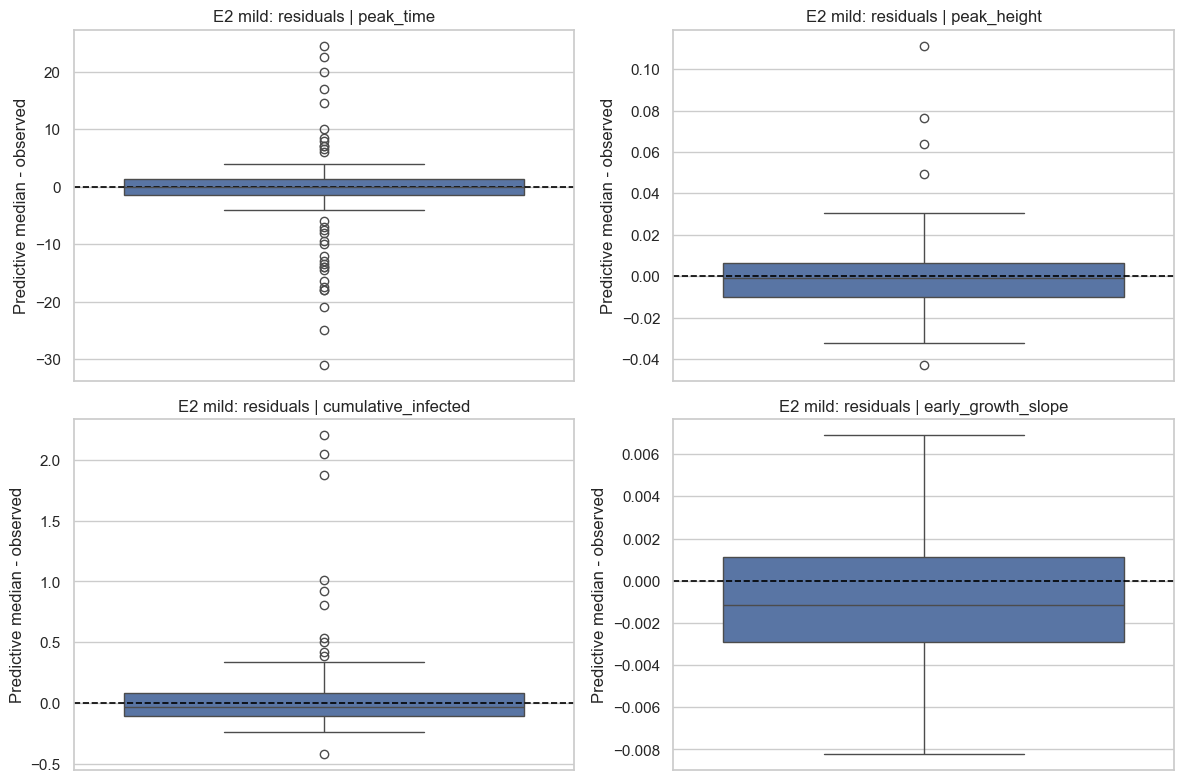

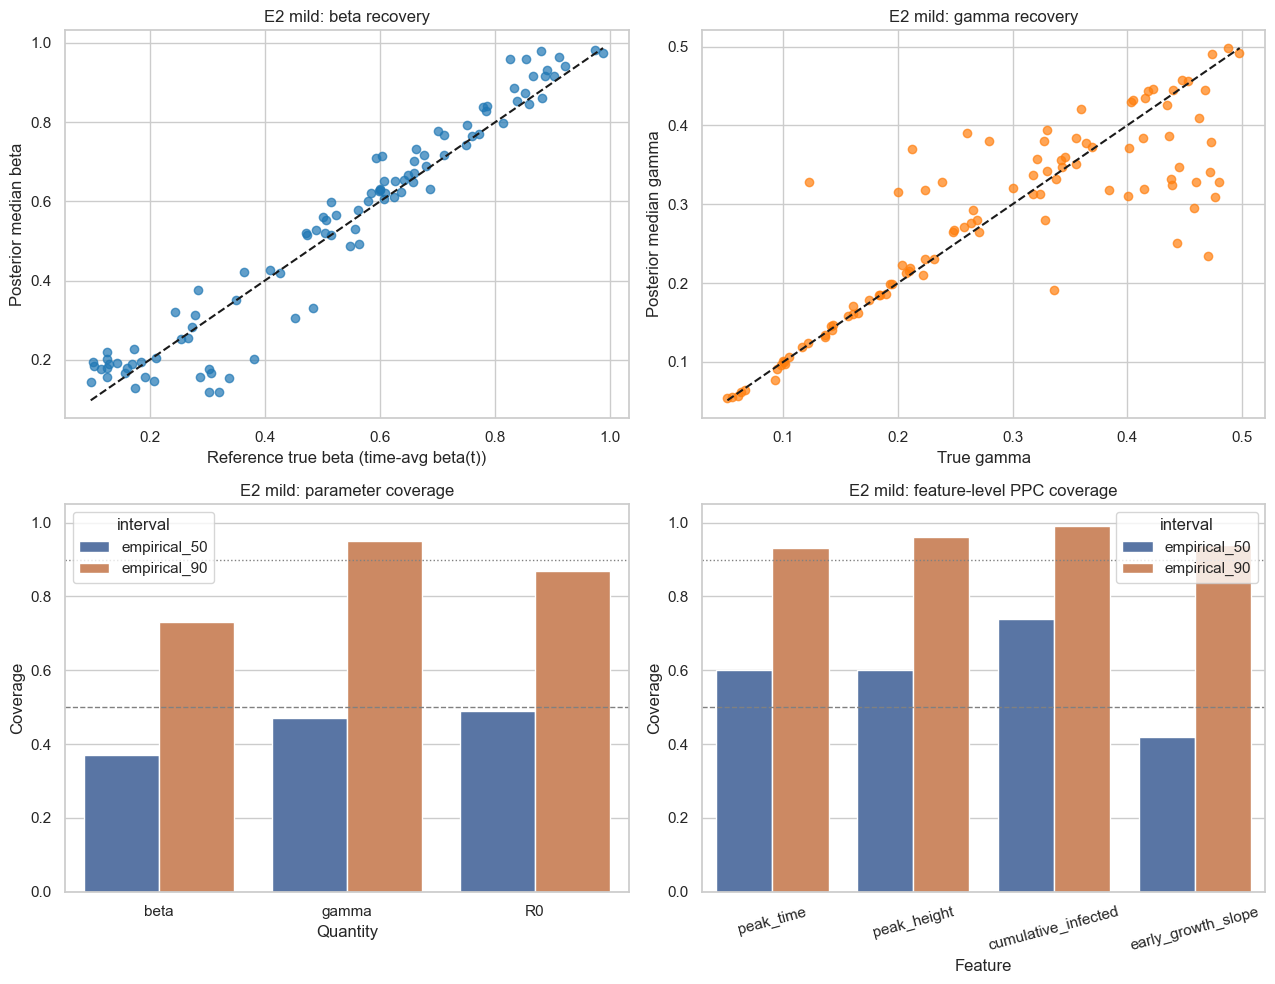

Saved:
  outputs_E2_mild/E2_case_level.csv
  outputs_E2_mild/E2_recovery_summary.csv
  outputs_E2_mild/E2_coverage_summary.csv
  outputs_E2_mild/E2_ppc_feature_case_level.csv
  outputs_E2_mild/E2_ppc_feature_summary.csv
  outputs_E2_mild/E2_overall_figure.png


In [23]:
severity_to_run = "mild"   

(
    case_df_E2,
    mild_recovery_df_E2,
    mild_coverage_df_E2,
    feature_case_df_E2,
    mild_feature_summary_df_E2,
) = run_E2_evaluation(
    workflow=workflow_E0,
    severity=severity_to_run,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2027,
)

print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())

print(f"\nE2 ({severity_to_run}) recovery summary:")
display(mild_recovery_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) coverage summary:")
display(mild_coverage_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")
display(mild_feature_summary_df_E2.round(4))



fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: beta recovery (reference beta)
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

# Panel B: gamma recovery
ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

# Panel C: parameter empirical vs nominal coverage
ax = axes[1, 0]
param_cov_plot_E2 = mild_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

# Panel D: feature-level PPC empirical vs nominal coverage
ax = axes[1, 1]
feat_cov_plot_E2 = mild_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


# residual boxplots for E2 feature-level PPC
plot_df_E2 = feature_case_df_E2.copy()
plot_df_E2["residual"] = plot_df_E2["err_median"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_order = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
]

for ax, feat in zip(axes, feature_order):
    sub = plot_df_E2[plot_df_E2["feature"] == feat].copy()
    sns.boxplot(data=sub, y="residual", ax=ax)
    ax.axhline(0.0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"E2 {severity_to_run}: residuals | {feat}")
    ax.set_xlabel("")
    ax.set_ylabel("Predictive median - observed")

plt.tight_layout()
plt.show()


out_dir_E2 = f"outputs_E2_{severity_to_run}"
os.makedirs(out_dir_E2, exist_ok=True)

case_df_E2.to_csv(f"{out_dir_E2}/E2_case_level.csv", index=False)
mild_recovery_df_E2.to_csv(f"{out_dir_E2}/E2_recovery_summary.csv", index=False)
mild_coverage_df_E2.to_csv(f"{out_dir_E2}/E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_case_level.csv", index=False)
mild_feature_summary_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# same 4-panel figure for saving
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

ax = axes[1, 0]
param_cov_plot_E2 = mild_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

ax = axes[1, 1]
feat_cov_plot_E2 = mild_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{out_dir_E2}/E2_overall_figure.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print(f"  {out_dir_E2}/E2_case_level.csv")
print(f"  {out_dir_E2}/E2_recovery_summary.csv")
print(f"  {out_dir_E2}/E2_coverage_summary.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_case_level.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_summary.csv")
print(f"  {out_dir_E2}/E2_overall_figure.png")

mild结论：
1. 在 mild misspecification 下，posterior recovery 整体仍保持较高相关性，说明 constant-β amortizer 还没有完全失去恢复能力。
2. beta 的 empirical coverage 已经明显低于 nominal，表明 transmission-related posterior calibration 是最先退化的部分。
3. feature-level PPC 在 mild 下 90% coverage 普遍偏高或尚可，而 50% coverage 有些feature明显偏离 nominal，不同 feature 差异很大。

Under mild time-varying transmission misspecification, posterior recovery remains fairly strong overall, but relative to the reference β and derived reference R0
，transmission-related posterior starts to distort. For β, the posterior median shows a small positive bias (bias_median_est = 0.0117) with MAE_median_est = 0.0504, while the truth–median correlation remains high (corr_truth_vs_median = 0.9699). For γ, recovery is still comparatively stable, with a small negative median bias (-0.0074), MAE_median_est = 0.0392, and corr_truth_vs_median = 0.8633. The derived quantity R0 already shows clearer upward distortion than β, with bias_median_est = 0.0947 and MAE_median_est = 0.1725, although its correlation with the reference truth remains high (0.9962).

The coverage results show that mild misspecification already affects posterior calibration, especially for β. Its empirical coverage falls below nominal at both levels (empirical_50 = 0.37 vs. nominal 0.50; empirical_90 = 0.73 vs. nominal 0.90), indicating under-coverage. By contrast, γ remains much more stable in coverage (empirical_50 = 0.47, empirical_90 = 0.95), and R0 shows only mild degradation (empirical_50 = 0.49, empirical_90 = 0.87). This pattern suggests that even weak dynamical misspecification first degrades uncertainty calibration for transmission-related quantities before it substantially disrupts the recovery of γ.

At the predictive level, the coarse feature-based PPC summaries do not show the same under-coverage pattern as β. Instead, they are mostly conservative at the 90% level: peak_time = 0.93, peak_height = 0.96, cumulative_infected = 0.99, and early_growth_slope = 0.94. Their 50% coverage values vary more across features (0.60, 0.60, 0.74, and 0.42, respectively), so the predictive summaries are not uniformly close to nominal. In particular, cumulative_infected is clearly over-covered, whereas early_growth_slope is the most sensitive among the four coarse summaries at the 50% level. Taken together, the mild results indicate that posterior calibration for β begins to deteriorate before low-dimensional predictive summaries show comparably strong failure, and when PPC intervals deviate from nominal they tend to do so in a conservative rather than sharply under-covered direction.

Sampling: 100%|██████████| 1/1 [00:00<00:00, 15.35batch/s]
INFO:bayesflow:Sampling completed in 0.25 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.38batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.45batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.31batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.56batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.13batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.43batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.64batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.40batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 


E2 (medium) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.086529,0.223647,0.386898,0.107205,0.223647,15,0.724475,medium,0.228021,...,0.083829,0.093013,0.093013,8.651337e-03,0.0,1.0,0.409688,0.381069,0.381069,0.145213
1,1,0.582976,0.142269,4.097702,0.702721,0.142269,11,0.781537,medium,0.690444,...,-0.000411,-0.000565,0.000565,3.189542e-07,0.0,0.0,0.778038,0.767836,0.767836,0.589573
2,2,0.399167,0.100655,3.965676,0.565901,0.100655,11,0.622263,medium,0.550525,...,-0.000371,-0.000518,0.000518,2.685726e-07,0.0,0.0,1.536159,1.528460,1.528460,2.336190
3,3,0.109347,0.458047,0.238725,0.132926,0.458047,20,0.704360,medium,0.209644,...,-0.164661,-0.156188,0.156188,2.439463e-02,0.0,0.0,0.554942,0.492621,0.492621,0.242675
4,4,0.651970,0.338086,1.928411,0.797830,0.338086,22,0.673533,medium,0.793349,...,-0.003766,-0.004377,0.004377,1.915664e-05,0.0,0.0,0.446829,0.441595,0.441595,0.195006



E2 (medium) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0972,0.0870,0.1110,0.128,0.9477,0.0583
1,gamma,-0.0038,0.0011,0.0455,0.072,0.8399,0.0470
2,R0,0.4130,0.3973,0.4082,0.544,0.9947,0.2323



E2 (medium) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.16,-0.34,0.9,0.32,-0.58,0.0725,0.1828
1,gamma,0.5,0.41,-0.09,0.9,0.82,-0.08,0.0756,0.1465
2,R0,0.5,0.19,-0.31,0.9,0.43,-0.47,0.3115,0.7512



E2 (medium) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.92,0.02,-0.1190,-0.6200,5.0800,8.3208,6.7409,10.4300,20.4150
1,peak_height,0.5,0.52,0.02,0.9,0.94,0.04,-0.0000,-0.0013,0.0129,0.0189,0.0204,0.0249,0.0614
2,cumulative_infected,0.5,0.70,0.20,0.9,0.99,0.09,0.0911,0.0572,0.2023,0.3868,0.3990,0.4297,1.1423
3,early_growth_slope,0.5,0.44,-0.06,0.9,0.92,0.02,-0.0012,-0.0011,0.0027,0.0034,0.0032,0.0043,0.0104


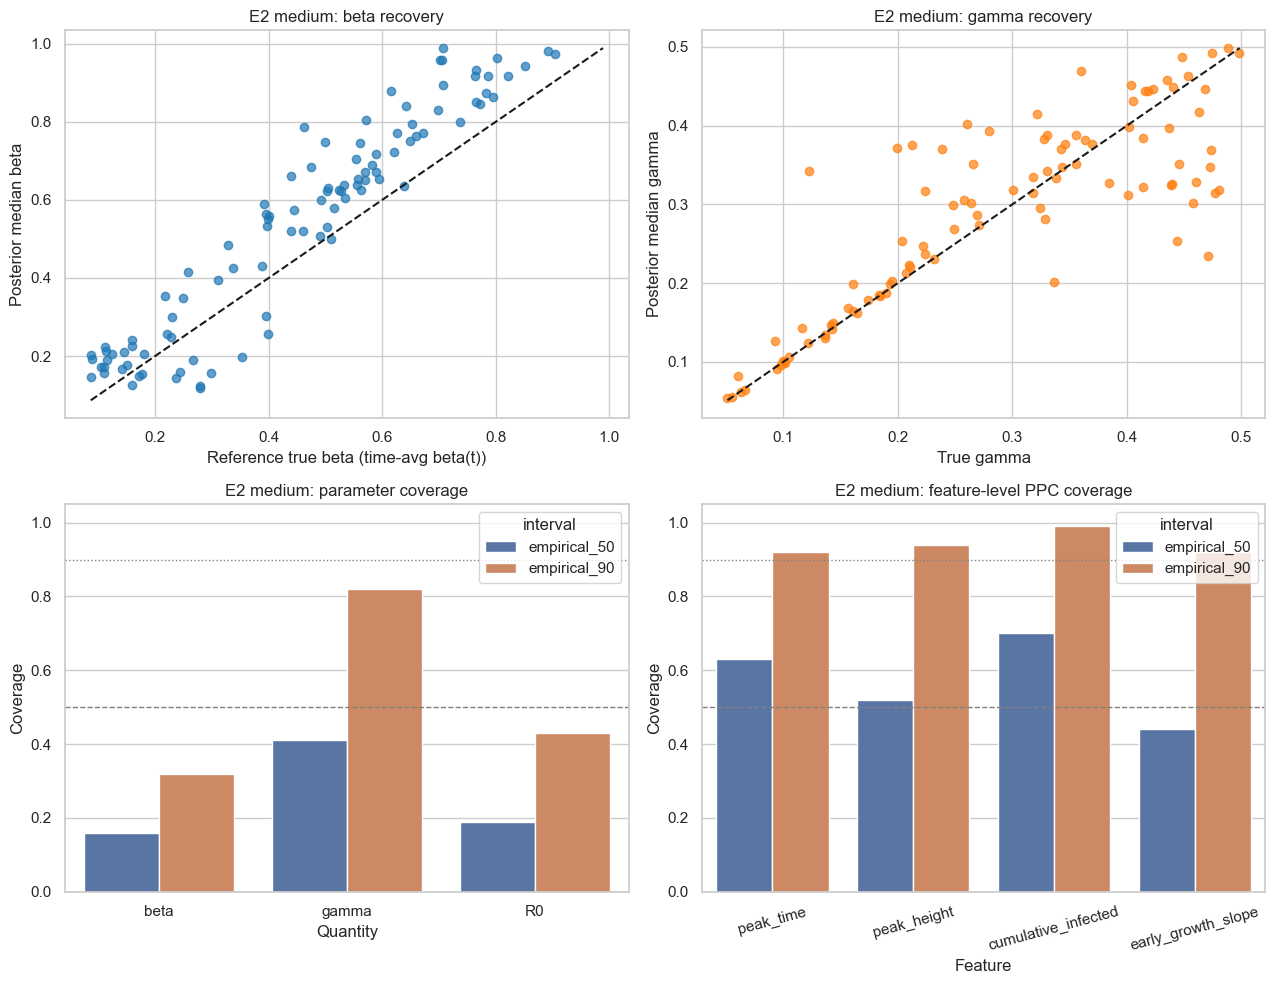

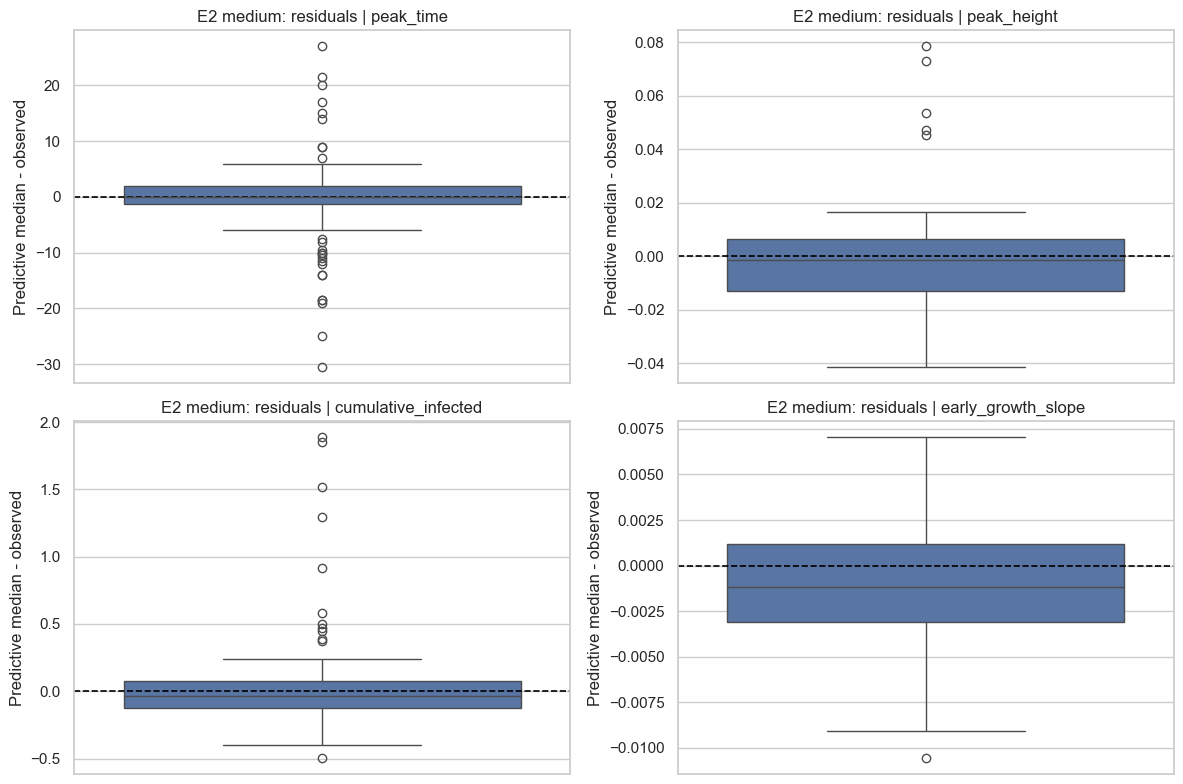

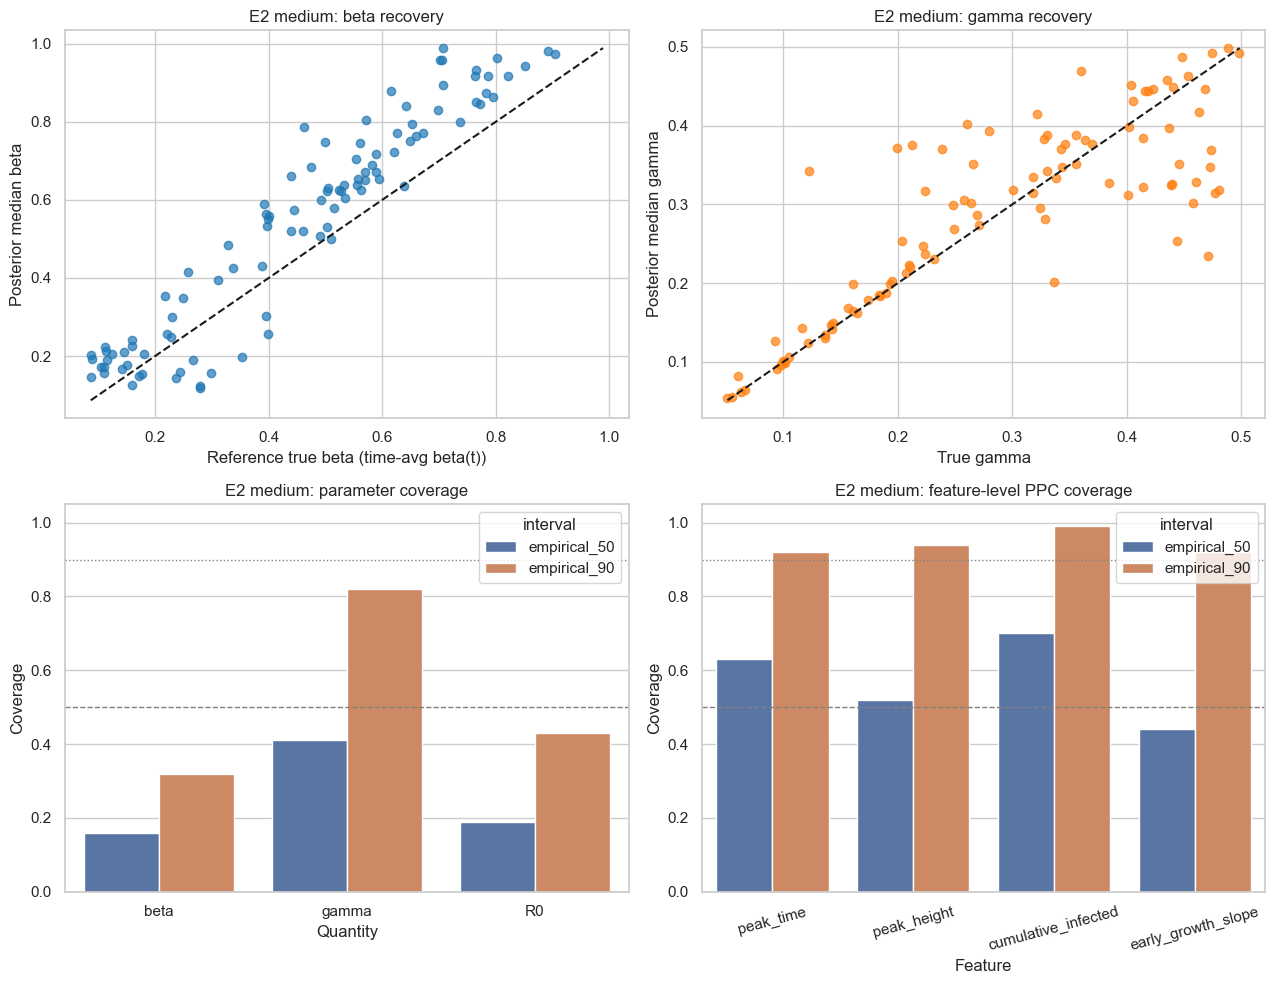

Saved:
  outputs_E2_medium/E2_case_level.csv
  outputs_E2_medium/E2_recovery_summary.csv
  outputs_E2_medium/E2_coverage_summary.csv
  outputs_E2_medium/E2_ppc_feature_case_level.csv
  outputs_E2_medium/E2_ppc_feature_summary.csv
  outputs_E2_medium/E2_overall_figure.png


In [24]:
# Run E2 evaluation for one severity level

severity_to_run = "medium"   

(
    case_df_E2,
    medium_recovery_df_E2,
    medium_coverage_df_E2,
    feature_case_df_E2,
    medium_feature_summary_df_E2,
) = run_E2_evaluation(
    workflow=workflow_E0,
    severity=severity_to_run,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2027,
)

print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())

print(f"\nE2 ({severity_to_run}) recovery summary:")
display(medium_recovery_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) coverage summary:")
display(medium_coverage_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")
display(medium_feature_summary_df_E2.round(4))



fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: beta recovery (reference beta)
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

# Panel B: gamma recovery
ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

# Panel C: parameter empirical vs nominal coverage
ax = axes[1, 0]
param_cov_plot_E2 = medium_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

# Panel D: feature-level PPC empirical vs nominal coverage
ax = axes[1, 1]
feat_cov_plot_E2 = medium_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


# residual boxplots for E2 feature-level PPC
plot_df_E2 = feature_case_df_E2.copy()
plot_df_E2["residual"] = plot_df_E2["err_median"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_order = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
]

for ax, feat in zip(axes, feature_order):
    sub = plot_df_E2[plot_df_E2["feature"] == feat].copy()
    sns.boxplot(data=sub, y="residual", ax=ax)
    ax.axhline(0.0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"E2 {severity_to_run}: residuals | {feat}")
    ax.set_xlabel("")
    ax.set_ylabel("Predictive median - observed")

plt.tight_layout()
plt.show()


out_dir_E2 = f"outputs_E2_{severity_to_run}"
os.makedirs(out_dir_E2, exist_ok=True)

case_df_E2.to_csv(f"{out_dir_E2}/E2_case_level.csv", index=False)
medium_recovery_df_E2.to_csv(f"{out_dir_E2}/E2_recovery_summary.csv", index=False)
medium_coverage_df_E2.to_csv(f"{out_dir_E2}/E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_case_level.csv", index=False)
medium_feature_summary_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# same 4-panel figure for saving
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

ax = axes[1, 0]
param_cov_plot_E2 = medium_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

ax = axes[1, 1]
feat_cov_plot_E2 = medium_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{out_dir_E2}/E2_overall_figure.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print(f"  {out_dir_E2}/E2_case_level.csv")
print(f"  {out_dir_E2}/E2_recovery_summary.csv")
print(f"  {out_dir_E2}/E2_coverage_summary.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_case_level.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_summary.csv")
print(f"  {out_dir_E2}/E2_overall_figure.png")

Under medium time-varying transmission misspecification, posterior recovery is still structured, but the degradation in transmission-related quantities becomes much more pronounced than in the mild setting. For β, the posterior median shows a clear positive bias (bias_median_est = 0.0870) with substantially larger error than under mild misspecification (MAE_median_est = 0.1110, RMSE_median_est = 0.1280), although the truth–median correlation remains fairly high (corr_truth_vs_median = 0.9477). For γ, the median bias remains close to zero (0.0011), with MAE_median_est = 0.0455 and corr_truth_vs_median = 0.8399, indicating that recovery of γ deteriorates only moderately. The derived quantity R0 shows much stronger distortion: its posterior median is clearly upward biased (bias_median_est = 0.3973), with MAE_median_est = 0.4082 and RMSE_median_est = 0.5440, even though the truth–median correlation remains high (0.9947). Thus, by the medium setting, the main effect of misspecification is no longer just a slight transmission bias, but a substantial upward distortion in transmission-related posterior summaries.

The coverage results confirm that posterior calibration degrades sharply at this severity level. For β, empirical coverage drops far below nominal values (empirical_50 = 0.16 vs. nominal 0.50; empirical_90 = 0.32 vs. nominal 0.90), indicating severe under-coverage. R0 behaves similarly (empirical_50 = 0.19, empirical_90 = 0.43), again showing strong under-coverage. In contrast, γ remains comparatively less affected, although its calibration also worsens relative to the mild case (empirical_50 = 0.41, empirical_90 = 0.82). Importantly, these large coverage losses are not offset by sufficiently wider intervals: for example, β still has avg_width90 = 0.1828, and R0 has avg_width90 = 0.7512. This pattern indicates that the posterior remains too concentrated relative to the true misspecification-induced uncertainty, especially for transmission-related quantities.

At the predictive level, the coarse feature-based PPC summaries again do not mirror the severe under-coverage seen in the posterior. Instead, their 90% predictive intervals remain high and generally conservative: peak_time = 0.92, peak_height = 0.94, cumulative_infected = 0.99, and early_growth_slope = 0.92. The 50% coverage values vary across features (0.63, 0.52, 0.70, and 0.44, respectively), so these summaries are not uniformly nominally calibrated, but they do not collapse in the same way as β and R0. The residual plots are consistent with this interpretation: peak_height remains centered close to zero, cumulative infected is roughly centered overall but shows a pronounced positive tail with several large positive outliers, and early growth slope remains slightly negatively centered. Overall, the medium results reveal a clear divergence between parameter-level and predictive-summary diagnostics: calibration relative to the transmission-related reference quantities deteriorates severely by this stage, whereas coarse low-dimensional PPC summaries remain broadly plausible and tend to be conservative rather than sharply under-covered.

Sampling: 100%|██████████| 1/1 [00:00<00:00, 15.18batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.54batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.51batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.17batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 12.93batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.09batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.05batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.09batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.24batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 


E2 (strong) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.065884,0.223647,0.294588,0.107205,0.223647,15,0.449370,strong,0.228657,...,0.089640,0.104142,0.104142,0.010846,0.0,0.0,0.498424,0.470109,0.470109,0.221002
1,1,0.438441,0.142269,3.081771,0.702721,0.142269,11,0.517845,strong,0.695510,...,0.002776,0.002543,0.002543,0.000006,0.0,0.0,1.721948,1.720111,1.720111,2.958780
2,2,0.268711,0.100655,2.669615,0.565901,0.100655,11,0.326715,strong,0.558294,...,0.007024,0.006810,0.006810,0.000046,0.0,0.0,2.527004,2.513059,2.513059,6.315466
3,3,0.087085,0.458047,0.190123,0.132926,0.458047,20,0.425232,strong,0.204942,...,-0.168151,-0.167692,0.167692,0.028121,0.0,0.0,0.593712,0.544566,0.544566,0.296552
4,4,0.524505,0.338086,1.551393,0.797830,0.338086,22,0.388240,strong,0.794490,...,-0.003040,-0.003310,0.003310,0.000011,0.0,0.0,0.822166,0.818501,0.818501,0.669943



E2 (strong) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.2010,0.1912,0.2035,0.2363,0.8873,0.0605
1,gamma,0.0072,0.0125,0.0567,0.0830,0.7901,0.0475
2,R0,0.8293,0.8150,0.8186,1.1259,0.9877,0.2289



E2 (strong) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.13,-0.37,0.9,0.22,-0.68,0.0750,0.1886
1,gamma,0.5,0.39,-0.11,0.9,0.71,-0.19,0.0756,0.1477
2,R0,0.5,0.13,-0.37,0.9,0.22,-0.68,0.3077,0.7385



E2 (strong) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.64,0.14,0.9,0.94,0.04,0.5480,-0.0350,5.0250,8.2081,6.9309,10.7725,21.2815
1,peak_height,0.5,0.47,-0.03,0.9,0.89,-0.01,-0.0034,-0.0051,0.0132,0.0178,0.0189,0.0231,0.0580
2,cumulative_infected,0.5,0.79,0.29,0.9,0.99,0.09,0.0530,0.0149,0.1329,0.1943,0.3498,0.3748,1.0332
3,early_growth_slope,0.5,0.41,-0.09,0.9,0.92,0.02,-0.0011,-0.0011,0.0028,0.0034,0.0033,0.0043,0.0105


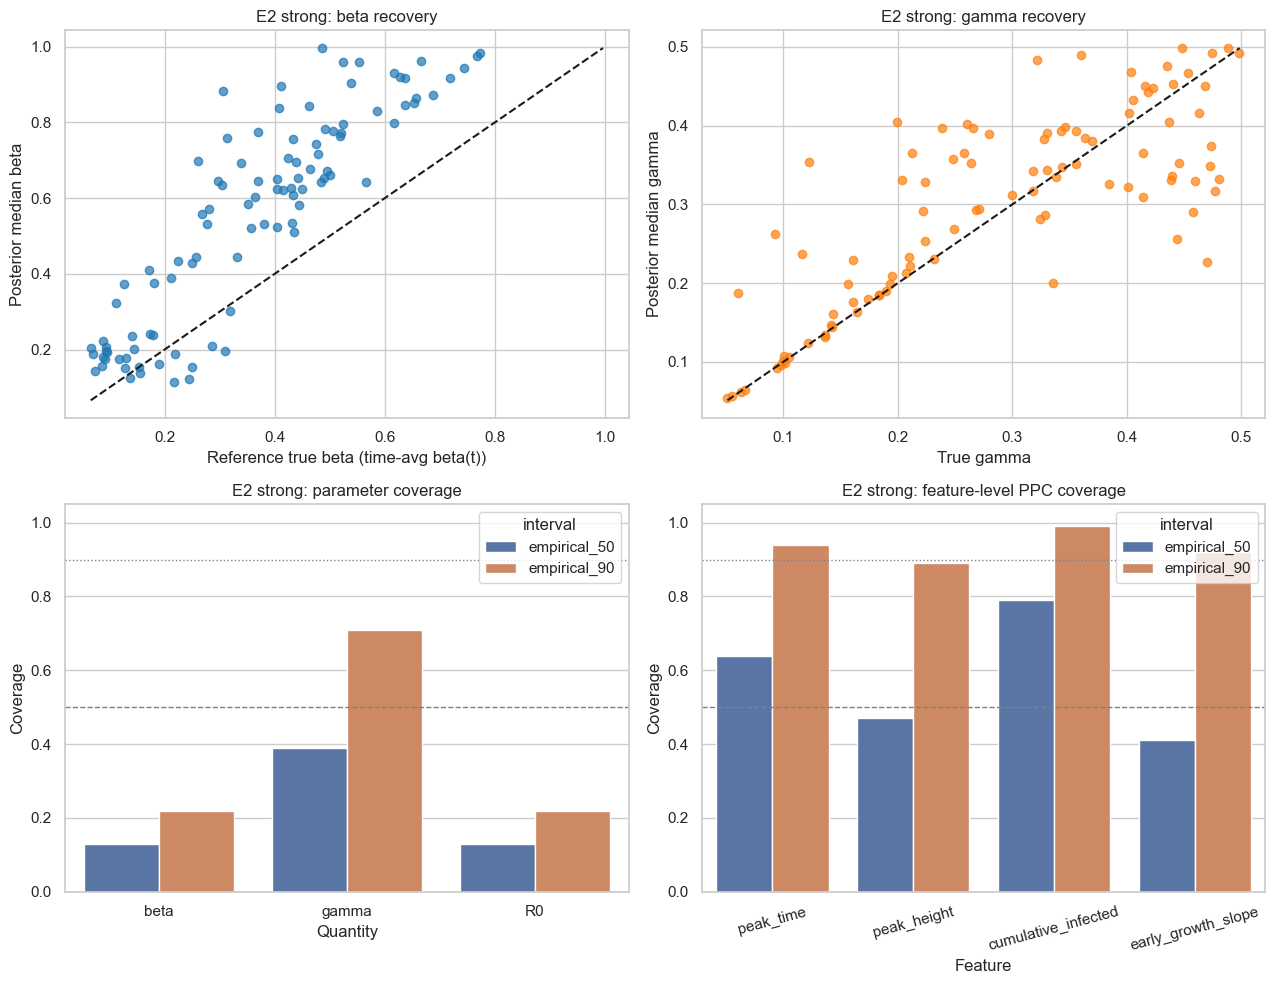

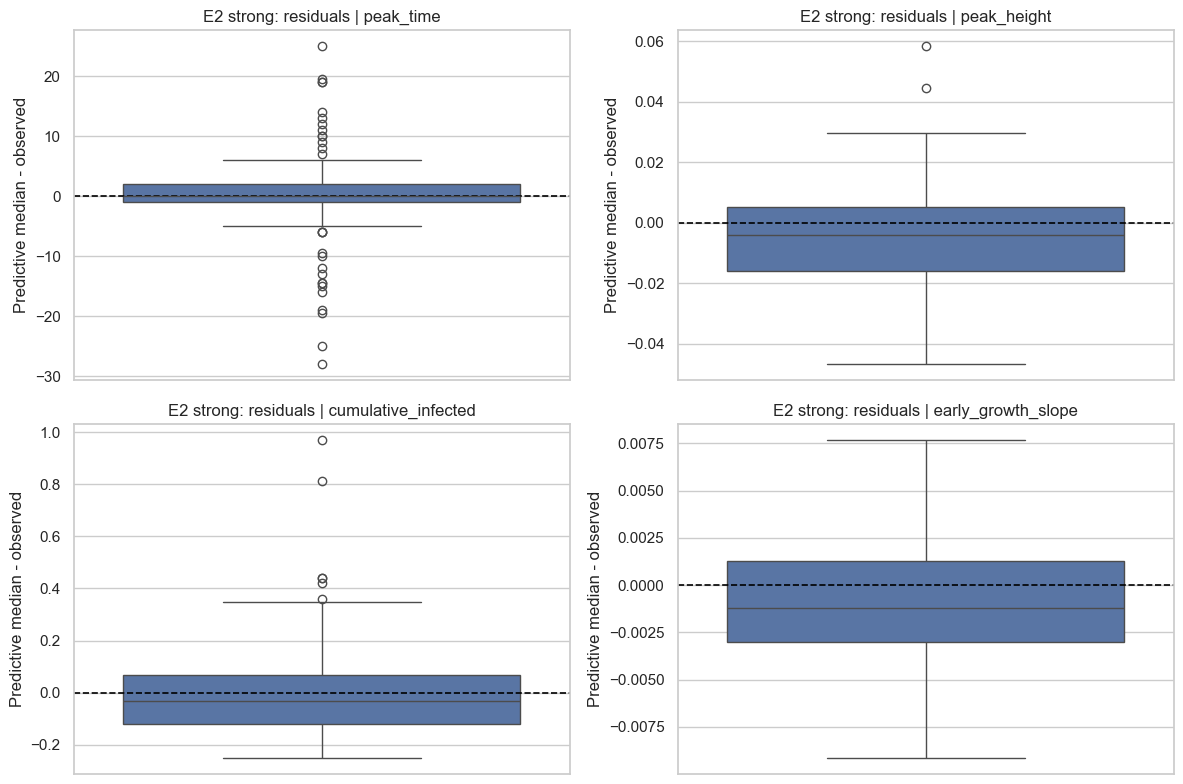

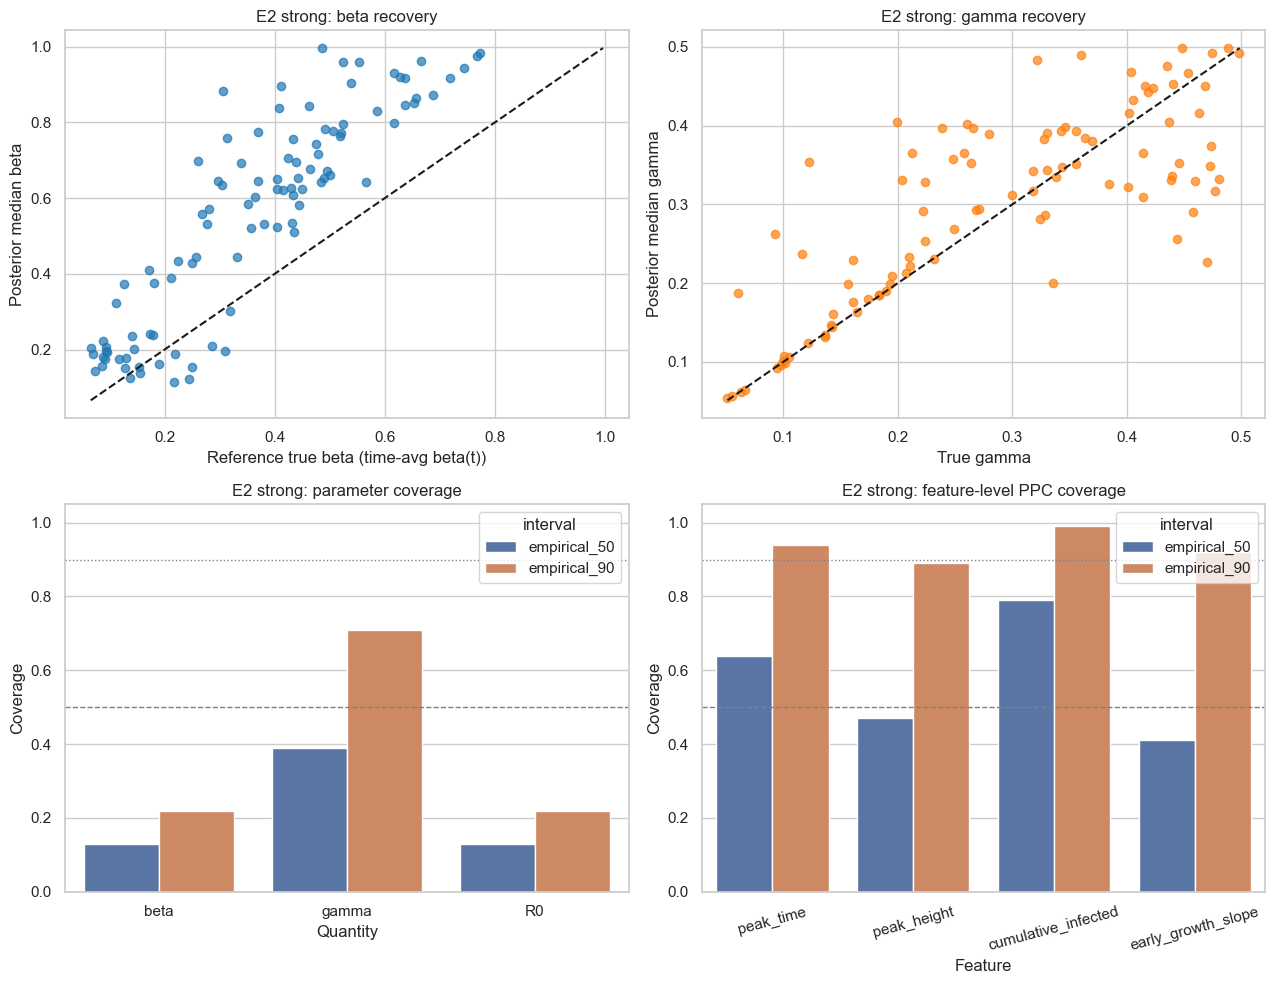

Saved:
  outputs_E2_strong/E2_case_level.csv
  outputs_E2_strong/E2_recovery_summary.csv
  outputs_E2_strong/E2_coverage_summary.csv
  outputs_E2_strong/E2_ppc_feature_case_level.csv
  outputs_E2_strong/E2_ppc_feature_summary.csv
  outputs_E2_strong/E2_overall_figure.png


In [25]:
# Run E2 evaluation for one severity level

severity_to_run = "strong"   

(
    case_df_E2,
    strong_recovery_df_E2,
    strong_coverage_df_E2,
    feature_case_df_E2,
    strong_feature_summary_df_E2,
) = run_E2_evaluation(
    workflow=workflow_E0,
    severity=severity_to_run,
    n_test=100,
    num_posterior_samples=2000,
    n_ppc_draws=100,
    seed=2027,
)

print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())

print(f"\nE2 ({severity_to_run}) recovery summary:")
display(strong_recovery_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) coverage summary:")
display(strong_coverage_df_E2.round(4))

print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")
display(strong_feature_summary_df_E2.round(4))



fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: beta recovery (reference beta)
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

# Panel B: gamma recovery
ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

# Panel C: parameter empirical vs nominal coverage
ax = axes[1, 0]
param_cov_plot_E2 = strong_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

# Panel D: feature-level PPC empirical vs nominal coverage
ax = axes[1, 1]
feat_cov_plot_E2 = strong_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


# residual boxplots for E2 feature-level PPC
plot_df_E2 = feature_case_df_E2.copy()
plot_df_E2["residual"] = plot_df_E2["err_median"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_order = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
]

for ax, feat in zip(axes, feature_order):
    sub = plot_df_E2[plot_df_E2["feature"] == feat].copy()
    sns.boxplot(data=sub, y="residual", ax=ax)
    ax.axhline(0.0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"E2 {severity_to_run}: residuals | {feat}")
    ax.set_xlabel("")
    ax.set_ylabel("Predictive median - observed")

plt.tight_layout()
plt.show()


out_dir_E2 = f"outputs_E2_{severity_to_run}"
os.makedirs(out_dir_E2, exist_ok=True)

case_df_E2.to_csv(f"{out_dir_E2}/E2_case_level.csv", index=False)
strong_recovery_df_E2.to_csv(f"{out_dir_E2}/E2_recovery_summary.csv", index=False)
strong_coverage_df_E2.to_csv(f"{out_dir_E2}/E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_case_level.csv", index=False)
strong_feature_summary_df_E2.to_csv(f"{out_dir_E2}/E2_ppc_feature_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# same 4-panel figure for saving
ax = axes[0, 0]
x = case_df_E2["true_beta"]
y = case_df_E2["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("Reference true beta (time-avg beta(t))")
ax.set_ylabel("Posterior median beta")
ax.set_title(f"E2 {severity_to_run}: beta recovery")

ax = axes[0, 1]
x = case_df_E2["true_gamma"]
y = case_df_E2["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title(f"E2 {severity_to_run}: gamma recovery")

ax = axes[1, 0]
param_cov_plot_E2 = strong_coverage_df_E2.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot_E2, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: parameter coverage")

ax = axes[1, 1]
feat_cov_plot_E2 = strong_feature_summary_df_E2.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot_E2, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title(f"E2 {severity_to_run}: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{out_dir_E2}/E2_overall_figure.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:")
print(f"  {out_dir_E2}/E2_case_level.csv")
print(f"  {out_dir_E2}/E2_recovery_summary.csv")
print(f"  {out_dir_E2}/E2_coverage_summary.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_case_level.csv")
print(f"  {out_dir_E2}/E2_ppc_feature_summary.csv")
print(f"  {out_dir_E2}/E2_overall_figure.png")

Under strong time-varying transmission misspecification, posterior recovery remains structured but becomes substantially distorted relative to the transmission-related reference quantities. For β, the posterior median shows a clear positive bias (bias_median_est = 0.1912) with much larger error than in the mild and medium settings (MAE_median_est = 0.2035, RMSE_median_est = 0.2363), while the truth–median correlation declines to 0.8873. For γ, recovery deteriorates more moderately: the median bias remains small and positive (0.0125), with MAE_median_est = 0.0567, RMSE_median_est = 0.0830, and corr_truth_vs_median = 0.7901. The strongest distortion is observed for R0, whose posterior median becomes heavily upward biased (bias_median_est = 0.8150), with MAE_median_est = 0.8186 and RMSE_median_est = 1.1259, even though the truth–median correlation remains high (0.9877). Thus, under strong misspecification, the posterior does not lose all ranking information, but its scale and calibration for transmission-related quantities are severely distorted.

The coverage results show a corresponding collapse in posterior calibration for β and R0. For β, empirical coverage drops to 0.13 for the 50% interval and 0.22 for the 90% interval, far below the nominal levels of 0.50 and 0.90. R0 shows the same pattern (empirical_50 = 0.13, empirical_90 = 0.22). Although γ remains less severely affected (0.39 and 0.71), it is no longer well calibrated either. These strong coverage failures are not matched by proportionally larger posterior widths, indicating that the posterior remains far too concentrated relative to the misspecification-induced uncertainty, especially for the transmission-related reference quantities.

At the predictive level, the coarse feature-based PPC summaries again do not exhibit the same severe under-coverage pattern. Their 90% predictive intervals remain mostly high: peak_time = 0.94, peak_height = 0.89, cumulative_infected = 0.99, and early_growth_slope = 0.92. The corresponding 50% coverage values vary across features (0.64, 0.47, 0.79, and 0.41), so these summaries are not uniformly nominally calibrated. In particular, cumulative_infected is strongly over-covered, peak_height is the least conservative of the four summaries at the 90% level, and early_growth_slope remains the least stable of the four coarse summaries at the 50% level. The residual plots are consistent with this pattern: peak_height stays centered close to zero, cumulative_infected shows a negative-centered bulk with several positive outliers, and early_growth_slope remains slightly negatively centered. Overall, the strong setting reinforces the same qualitative conclusion as the medium one, but more sharply: posterior calibration for β and R0 collapses under severe misspecification, whereas low-dimensional predictive summaries remain much less sensitive and often conservative rather than strongly under-covered.

## E2 severity summary + line plots

E2 severity summary:


,severity,beta_bias_median,beta_MAE,beta_empirical_90,gamma_empirical_90,R0_empirical_90,peak_time_MAE,early_growth_slope_empirical_50
0,mild,0.0117,0.0504,0.73,0.95,0.87,5.115,0.42
1,medium,0.0870,0.1110,0.32,0.82,0.43,5.080,0.44
2,strong,0.1912,0.2035,0.22,0.71,0.22,5.025,0.41


Saved:
  outputs_E2_severity_summary/E2_severity_summary.csv


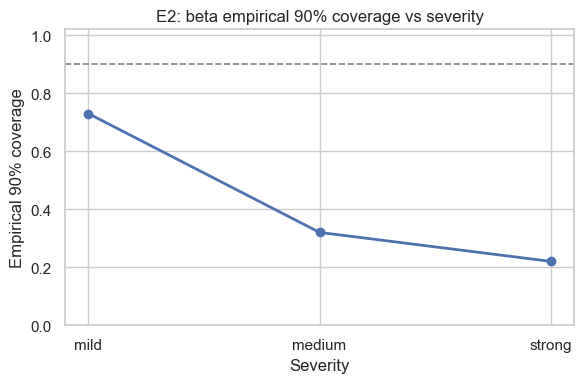

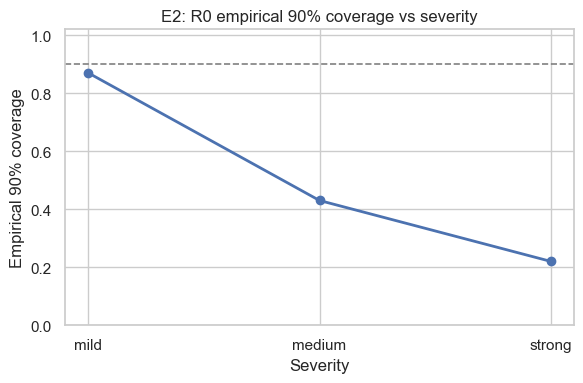

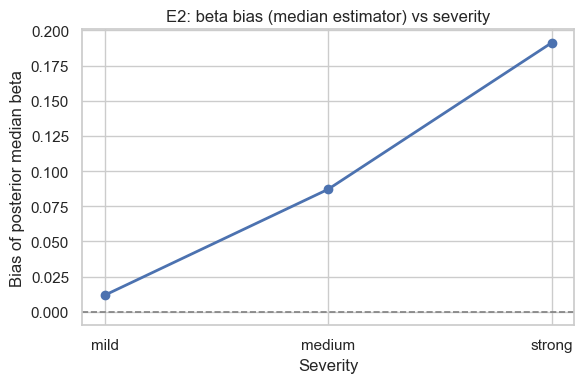

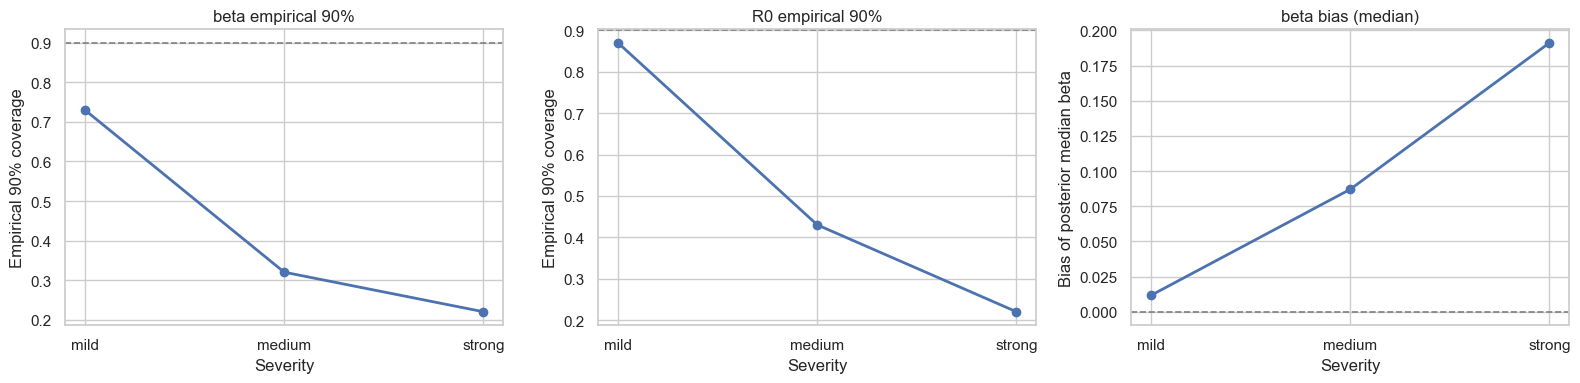

Saved severity plots:
  outputs_E2_severity_summary/E2_beta_empirical90_vs_severity.png
  outputs_E2_severity_summary/E2_R0_empirical90_vs_severity.png
  outputs_E2_severity_summary/E2_beta_bias_median_vs_severity.png
  outputs_E2_severity_summary/E2_severity_3panel_summary.png


In [48]:
# E2-main(4 features)

def extract_single_value(df, row_key_col, row_key, value_col):
    """
    Helper: extract one scalar value from a tidy summary DataFrame.
    """
    sub = df[df[row_key_col] == row_key]
    if len(sub) != 1:
        raise ValueError(
            f"Expected exactly one row where {row_key_col} == {row_key}, "
            f"but got {len(sub)} rows."
        )
    return float(sub.iloc[0][value_col])


def build_E2_severity_summary(
    mild_recovery_df_E2,
    mild_coverage_df_E2,
    mild_feature_summary_df_E2,
    medium_recovery_df_E2,
    medium_coverage_df_E2,
    medium_feature_summary_df_E2,
    strong_recovery_df_E2,
    strong_coverage_df_E2,
    strong_feature_summary_df_E2,
):
    """
    Build a compact severity-level summary table for E2.

    Output columns:
        severity
        beta_bias_median
        beta_MAE
        beta_empirical_90
        gamma_empirical_90
        R0_empirical_90
        peak_time_MAE
        early_growth_slope_empirical_50
    """
    rows = []

    severity_blocks = [
        ("mild", mild_recovery_df_E2, mild_coverage_df_E2, mild_feature_summary_df_E2),
        ("medium", medium_recovery_df_E2, medium_coverage_df_E2, medium_feature_summary_df_E2),
        ("strong", strong_recovery_df_E2, strong_coverage_df_E2, strong_feature_summary_df_E2),
    ]

    for severity, recovery_df, coverage_df, feature_summary_df in severity_blocks:
        row = {
            "severity": severity,

            "beta_bias_median": extract_single_value(
                recovery_df, "quantity", "beta", "bias_median_est"
            ),
            "beta_MAE": extract_single_value(
                recovery_df, "quantity", "beta", "MAE_median_est"
            ),
            "beta_empirical_90": extract_single_value(
                coverage_df, "quantity", "beta", "empirical_90"
            ),
            "gamma_empirical_90": extract_single_value(
                coverage_df, "quantity", "gamma", "empirical_90"
            ),
            "R0_empirical_90": extract_single_value(
                coverage_df, "quantity", "R0", "empirical_90"
            ),
            "peak_time_MAE": extract_single_value(
                feature_summary_df, "feature", "peak_time", "MAE_median_pred"
            ),
            "early_growth_slope_empirical_50": extract_single_value(
                feature_summary_df, "feature", "early_growth_slope", "empirical_50"
            ),
        }
        rows.append(row)

    summary_df = pd.DataFrame(rows)

    # enforce plotting order
    severity_order = ["mild", "medium", "strong"]
    summary_df["severity"] = pd.Categorical(
        summary_df["severity"],
        categories=severity_order,
        ordered=True,
    )
    summary_df = summary_df.sort_values("severity").reset_index(drop=True)

    return summary_df


def plot_E2_severity_lines(summary_df, out_dir="outputs_E2_severity_summary"):
    """
    Make 3 line plots:
      1) beta_empirical_90 vs severity
      2) R0_empirical_90 vs severity
      3) beta_bias_median vs severity
    """
    os.makedirs(out_dir, exist_ok=True)

    # -------- Plot 1: beta_empirical_90 --------
    plt.figure(figsize=(6, 4))
    plt.plot(
        summary_df["severity"].astype(str),
        summary_df["beta_empirical_90"],
        marker="o",
        lw=2,
    )
    plt.axhline(0.90, color="gray", linestyle="--", lw=1.2)
    plt.xlabel("Severity")
    plt.ylabel("Empirical 90% coverage")
    plt.title("E2: beta empirical 90% coverage vs severity")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/E2_beta_empirical90_vs_severity.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    # -------- Plot 2: R0_empirical_90 --------
    plt.figure(figsize=(6, 4))
    plt.plot(
        summary_df["severity"].astype(str),
        summary_df["R0_empirical_90"],
        marker="o",
        lw=2,
    )
    plt.axhline(0.90, color="gray", linestyle="--", lw=1.2)
    plt.xlabel("Severity")
    plt.ylabel("Empirical 90% coverage")
    plt.title("E2: R0 empirical 90% coverage vs severity")
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/E2_R0_empirical90_vs_severity.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    # -------- Plot 3: beta_bias_median --------
    plt.figure(figsize=(6, 4))
    plt.plot(
        summary_df["severity"].astype(str),
        summary_df["beta_bias_median"],
        marker="o",
        lw=2,
    )
    plt.axhline(0.0, color="gray", linestyle="--", lw=1.2)
    plt.xlabel("Severity")
    plt.ylabel("Bias of posterior median beta")
    plt.title("E2: beta bias (median estimator) vs severity")
    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/E2_beta_bias_median_vs_severity.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    # -------- Combined 3-panel figure --------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(
        summary_df["severity"].astype(str),
        summary_df["beta_empirical_90"],
        marker="o",
        lw=2,
    )
    axes[0].axhline(0.90, color="gray", linestyle="--", lw=1.2)
    axes[0].set_xlabel("Severity")
    axes[0].set_ylabel("Empirical 90% coverage")
    axes[0].set_title("beta empirical 90%")

    axes[1].plot(
        summary_df["severity"].astype(str),
        summary_df["R0_empirical_90"],
        marker="o",
        lw=2,
    )
    axes[1].axhline(0.90, color="gray", linestyle="--", lw=1.2)
    axes[1].set_xlabel("Severity")
    axes[1].set_ylabel("Empirical 90% coverage")
    axes[1].set_title("R0 empirical 90%")

    axes[2].plot(
        summary_df["severity"].astype(str),
        summary_df["beta_bias_median"],
        marker="o",
        lw=2,
    )
    axes[2].axhline(0.0, color="gray", linestyle="--", lw=1.2)
    axes[2].set_xlabel("Severity")
    axes[2].set_ylabel("Bias of posterior median beta")
    axes[2].set_title("beta bias (median)")

    plt.tight_layout()
    fig.savefig(
        f"{out_dir}/E2_severity_3panel_summary.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved severity plots:")
    print(f"  {out_dir}/E2_beta_empirical90_vs_severity.png")
    print(f"  {out_dir}/E2_R0_empirical90_vs_severity.png")
    print(f"  {out_dir}/E2_beta_bias_median_vs_severity.png")
    print(f"  {out_dir}/E2_severity_3panel_summary.png")



E2_severity_summary_df = build_E2_severity_summary(
    mild_recovery_df_E2=mild_recovery_df_E2,
    mild_coverage_df_E2=mild_coverage_df_E2,
    mild_feature_summary_df_E2=mild_feature_summary_df_E2,

    medium_recovery_df_E2=medium_recovery_df_E2,
    medium_coverage_df_E2=medium_coverage_df_E2,
    medium_feature_summary_df_E2=medium_feature_summary_df_E2,

    strong_recovery_df_E2=strong_recovery_df_E2,
    strong_coverage_df_E2=strong_coverage_df_E2,
    strong_feature_summary_df_E2=strong_feature_summary_df_E2,
)

print("E2 severity summary:")
display(E2_severity_summary_df.round(4))

os.makedirs("outputs_E2_severity_summary", exist_ok=True)
E2_severity_summary_df.to_csv(
    "outputs_E2_severity_summary/E2_severity_summary.csv",
    index=False,
)

print("Saved:")
print("  outputs_E2_severity_summary/E2_severity_summary.csv")

plot_E2_severity_lines(
    E2_severity_summary_df,
    out_dir="outputs_E2_severity_summary",
)

Under E2, posterior degradation increases systematically with misspecification severity. The median bias of beta rises monotonically from mild to strong misspecification, while empirical 90% coverage for beta and R0 drops sharply. In contrast, gamma degrades more moderately. Coarse feature-level PPC summaries remain comparatively stable, suggesting that predictive adequacy assessed through low-dimensional summaries may appear superficially acceptable even when parameter posteriors are already substantially miscalibrated.
1. 时变 transmission misspecification 主要先破坏 transmission-related quantities（beta 和 R0）的 posterior reliability，而 gamma 相对更稳。
2. 当前的这两个 PPC 指标对 severity 不敏感。


The E2 severity summary reveals a clear severity-dependent pattern, with the strongest effects concentrated in the transmission-related reference posterior diagnostics. Most notably, the posterior median bias for the reference transmission quantity β increases monotonically as misspecification becomes stronger: 0.0117 under mild misspecification, 0.0870 under medium misspecification, and 0.1912 under strong misspecification. The corresponding β MAE values also rise steadily (0.0504 → 0.1110 → 0.2035), indicating progressively larger point-estimation error relative to the reference scalar β as time-varying transmission misspecification strengthens. Thus, the first severity trend is a systematic increase in upward distortion of the transmission-related posterior.

A second and even more striking trend appears in posterior calibration. For β, empirical 90% coverage drops sharply from 0.73 in the mild setting to 0.32 in the medium setting and 0.22 in the strong setting. The same pattern is observed for the reference quantity R0, whose empirical 90% coverage declines from 0.87 to 0.43 and then to 0.22. These line plots show a clear monotonic deterioration away from the nominal 90% level, indicating that increasing misspecification severity manifests primarily as increasingly severe under-coverage for the transmission-related reference quantities. By contrast, γ is comparatively more stable: its empirical 90% coverage decreases from 0.95 to 0.82 and then to 0.71, which still indicates degradation, but at a more moderate rate than for β and R0. Taken together, these trends show a progressive deterioration in calibration, becoming particularly severe for the transmission-related reference quantities.

At the predictive-summary level, however, the same severity pattern is not clearly visible in the coarse summaries considered here. For example, peak_time MAE remains nearly unchanged across the three settings (5.115, 5.080, 5.025), and early_growth_slope empirical 50% coverage also varies only slightly (0.42, 0.44, 0.41) without a monotonic trend. This indicates that the coarse predictive summaries included in the severity table do not track misspecification severity nearly as clearly as the posterior diagnostics do. Therefore, the severity summary supports a central conclusion of E2: as time-varying transmission misspecification becomes stronger, posterior distortion and under-coverage increase markedly for β and the reference R0, whereas coarse predictive summaries remain comparatively insensitive and do not exhibit an equally strong severity-dependent deterioration.


In [49]:
extended_feature_names = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
    "post_peak_decline_slope",
    "late_phase_auc",
    "time_to_half_peak_after_peak",
    "late_to_early_mean_ratio",
]

feature_case_df_E2_ext, feature_summary_df_E2_ext = extended_evaluate_feature_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="medium"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    feature_names=extended_feature_names,
    extract_feature_kwargs={
        "early_days": 8,
        "post_peak_days": 8,
        "late_start_frac": 0.5,
    },
)

print("\nExtended feature-level PPC summary (E2 medium):")
display(feature_summary_df_E2_ext.round(4))

Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.59batch/s]
INFO:bayesflow:Sampling completed in 0.28 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.29batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.08batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.41batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.06batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.70batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.81batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.75batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.17batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 


Extended feature-level PPC summary (E2 medium):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.60,0.10,0.9,0.97,0.07,0.6227,0.1650,4.3050,7.1615,5.5619,8.5275,17.0095
1,peak_height,0.5,0.50,0.00,0.9,0.94,0.04,0.0014,0.0003,0.0161,0.0243,0.0202,0.0256,0.0627
2,cumulative_infected,0.5,0.73,0.23,0.9,0.98,0.08,0.1069,0.0884,0.2167,0.4251,0.3783,0.4411,1.1389
3,early_growth_slope,0.5,0.43,-0.07,0.9,0.90,0.00,-0.0011,-0.0011,0.0025,0.0030,0.0032,0.0041,0.0101
4,post_peak_decline_slope,0.5,0.57,0.07,0.9,0.91,0.01,0.0003,0.0006,0.0024,0.0031,0.0042,0.0041,0.0111
5,late_phase_auc,0.5,0.61,0.11,0.9,0.94,0.04,0.1351,0.1254,0.1650,0.3701,0.2213,0.2503,0.6453
6,time_to_half_peak_after_peak,0.5,0.73,0.23,0.9,0.94,0.04,0.3049,0.0700,1.1800,1.9066,1.7883,2.1300,5.0960
7,late_to_early_mean_ratio,0.5,0.50,0.00,0.9,0.95,0.05,0.0850,0.0560,0.1263,0.2211,0.1984,0.2309,0.6047


In [50]:
feature_case_df_E2_ext, feature_summary_df_E2_ext = extended_evaluate_feature_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="mild"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    feature_names=extended_feature_names,
    extract_feature_kwargs={
        "early_days": 8,
        "post_peak_days": 8,
        "late_start_frac": 0.5,
    },
)

print("\nExtended feature-level PPC summary (E2 mild):")
display(feature_summary_df_E2_ext.round(4))

Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.74batch/s]
INFO:bayesflow:Sampling completed in 0.24 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.09batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.03batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.48batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.14batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.42batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.39batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.63batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.80batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 


Extended feature-level PPC summary (E2 mild):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.65,0.15,0.9,0.97,0.07,0.5140,0.2800,4.2400,7.2471,5.4836,8.6425,16.8795
1,peak_height,0.5,0.55,0.05,0.9,0.96,0.06,-0.0000,-0.0009,0.0131,0.0187,0.0214,0.0261,0.0669
2,cumulative_infected,0.5,0.73,0.23,0.9,0.98,0.08,0.0870,0.0582,0.1956,0.3607,0.4139,0.4769,1.2569
3,early_growth_slope,0.5,0.45,-0.05,0.9,0.89,-0.01,-0.0011,-0.0010,0.0024,0.0029,0.0032,0.0041,0.0101
4,post_peak_decline_slope,0.5,0.58,0.08,0.9,0.92,0.02,0.0003,0.0005,0.0023,0.0031,0.0041,0.0041,0.0111
5,late_phase_auc,0.5,0.59,0.09,0.9,0.95,0.05,0.1168,0.1067,0.1564,0.3092,0.2511,0.2786,0.7333
6,time_to_half_peak_after_peak,0.5,0.72,0.22,0.9,0.96,0.06,0.1979,-0.0800,1.1700,2.0149,1.8377,2.1475,5.4275
7,late_to_early_mean_ratio,0.5,0.57,0.07,0.9,0.95,0.05,0.0581,0.0265,0.1136,0.1912,0.2132,0.2486,0.6485


In [51]:
feature_case_df_E2_ext, feature_summary_df_E2_ext = extended_evaluate_feature_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="strong"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    feature_names=extended_feature_names,
    extract_feature_kwargs={
        "early_days": 8,
        "post_peak_days": 8,
        "late_start_frac": 0.5,
    },
)

print("\nExtended feature-level PPC summary (E2 strong):")
display(feature_summary_df_E2_ext.round(4))

Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.19batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.11batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.98batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.26batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.18batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.24batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.42batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.92batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.26batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 


Extended feature-level PPC summary (E2 strong):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.65,0.15,0.9,0.95,0.05,0.7507,0.3500,4.4000,7.1593,5.7264,8.7850,17.5840
1,peak_height,0.5,0.47,-0.03,0.9,0.90,0.00,-0.0020,-0.0034,0.0156,0.0222,0.0192,0.0246,0.0602
2,cumulative_infected,0.5,0.75,0.25,0.9,0.98,0.08,0.0795,0.0501,0.1566,0.2429,0.3430,0.3981,1.0322
3,early_growth_slope,0.5,0.46,-0.04,0.9,0.92,0.02,-0.0011,-0.0010,0.0025,0.0030,0.0031,0.0041,0.0100
4,post_peak_decline_slope,0.5,0.54,0.04,0.9,0.90,0.00,0.0006,0.0009,0.0025,0.0034,0.0041,0.0039,0.0108
5,late_phase_auc,0.5,0.53,0.03,0.9,0.92,0.02,0.1088,0.0901,0.1215,0.2028,0.1881,0.2017,0.5489
6,time_to_half_peak_after_peak,0.5,0.71,0.21,0.9,0.92,0.02,0.0989,-0.1800,1.2700,2.0384,1.7603,2.0925,5.0245
7,late_to_early_mean_ratio,0.5,0.43,-0.07,0.9,0.91,0.01,0.0928,0.0627,0.1228,0.1968,0.1930,0.2243,0.5918


The extended feature-level PPC analysis was designed to test whether more dynamics-aware summaries would reveal a clearer misspecification signal than the original four coarse features. Across the three severity settings, however, the results show that these extended summaries still do not exhibit a severity trend as sharp as the one observed for the parameter-level posterior diagnostics. Instead, most extended predictive intervals remain comparatively high at the 90% level, and the differences across mild, medium, and strong settings are modest.

For the original coarse summaries, the pattern remains broadly consistent with the earlier PPC results. For example, peak_time retains high empirical 90% coverage across all three settings (0.97, 0.97, 0.95 for mild, medium, and strong), while its 50% coverage stays above nominal (0.65, 0.60, 0.65). cumulative_infected is also consistently over-covered, with empirical 90% coverage of 0.98, 0.98, and 0.98, and empirical 50% coverage of 0.73, 0.73, and 0.75. By contrast, early_growth_slope remains the most sensitive of the original summaries at the 50% level, but even here the variation across severity is small (0.45, 0.43, 0.46), and empirical 90% coverage remains close to or above nominal (0.89, 0.90, 0.92). Thus, even before considering the newly added features, the extended tables reinforce the earlier conclusion that coarse predictive summaries remain comparatively stable and often conservative.

Among the newly introduced dynamics-aware summaries, post_peak_decline_slope does not show strong severity sensitivity. Its empirical 90% coverage remains close to nominal in all three settings (0.92, 0.91, 0.90), and its median prediction error remains very small (MAE_median_pred = 0.0023, 0.0024, 0.0025). This suggests that the short post-peak slope, as defined here, is not strongly disrupted by the time-varying transmission misspecification, at least not in a way that produces a sharp change in predictive coverage.

late_phase_auc is somewhat more informative, but still does not display a strong monotonic deterioration. Its empirical 90% coverage decreases only moderately across the three settings (0.95, 0.94, 0.92), while MAE_median_pred does not increase monotonically (0.1564, 0.1650, 0.1215). At the same time, bias_median_pred remains positive across all three settings (0.1067, 0.1254, 0.0901), suggesting a recurring tendency toward overprediction in the late phase rather than a sharp severity-dependent calibration failure. Thus, late_phase_auc captures some systematic mismatch, but the effect is expressed more as a mild directional bias than as a strong severity-dependent coverage breakdown.

A similar pattern holds for time_to_half_peak_after_peak. This feature remains highly covered at the 90% level (0.96, 0.94, 0.92) and substantially over-covered at the 50% level (0.72, 0.73, 0.71). Its MAE_median_pred is also relatively large in all three settings (1.1700, 1.1800, 1.2700), but the increase with severity is modest. This means that the feature is not especially sharp as a severity discriminator: it reflects nontrivial predictive error, but the intervals are wide enough that empirical coverage remains high.

Finally, late_to_early_mean_ratio also fails to produce a clear severity-dependent breakdown. Its empirical 90% coverage is 0.95, 0.95, and 0.91, while its empirical 50% coverage moves from 0.57 to 0.50 and then to 0.43. This does suggest some decline at the 50% level, but the pattern is much weaker than the one seen for posterior calibration of the reference quantities β and R0, and even under strong misspecification the empirical 90% coverage remains near nominal.

Overall, the extended feature-level PPC results do not overturn the main conclusion from the original PPC analysis. Even when using more dynamics-aware summaries such as post_peak_decline_slope, late_phase_auc, time_to_half_peak_after_peak, and late_to_early_mean_ratio, the predictive summaries still do not show a severity-dependent deterioration nearly as strong as the one observed at the posterior parameter level. The main misspecification signal therefore remains concentrated in the calibration and bias of the transmission-related reference posterior quantities—especially β and R0—whereas feature-level predictive summaries, even when made more dynamics-aware, remain comparatively insensitive and often conservative rather than sharply under-covered.


## 在整条感染曲线层面，constant-β posterior predictive 到底在哪些时间段开始跟不上 time-varying β(t) 的观测？而且这种 discrepancy 会不会随 severity 变强？

In [ ]:
def summarize_predictive_curves(ppc_curves):
    """
    Summarize posterior predictive curves across draws.

    Args:
        ppc_curves: np.ndarray of shape (n_draws, T)

    Returns:
        dict with mean / median / q05 / q25 / q75 / q95, each shape (T,)
    """
    ppc_curves = np.asarray(ppc_curves, dtype=float)

    return {
        "mean": np.mean(ppc_curves, axis=0),
        "median": np.median(ppc_curves, axis=0),
        "q05": np.quantile(ppc_curves, 0.05, axis=0),
        "q25": np.quantile(ppc_curves, 0.25, axis=0),
        "q75": np.quantile(ppc_curves, 0.75, axis=0),
        "q95": np.quantile(ppc_curves, 0.95, axis=0),
    }


def compute_curve_discrepancy(observed_curve, predictive_median_curve, split_frac=0.5):
    """
    Compute curve-level discrepancy metrics between observed curve and
    posterior predictive median curve.

    Args:
        observed_curve: shape (T,)
        predictive_median_curve: shape (T,)
        split_frac: split point for early/late windows

    Returns:
        dict of scalar discrepancy metrics
    """
    y_obs = np.asarray(observed_curve, dtype=float).reshape(-1)
    y_pred = np.asarray(predictive_median_curve, dtype=float).reshape(-1)

    if len(y_obs) != len(y_pred):
        raise ValueError("observed_curve and predictive_median_curve must have same length.")

    err = y_pred - y_obs
    abs_err = np.abs(err)
    sq_err = err ** 2

    n = len(y_obs)
    split_idx = int(np.floor(split_frac * n))
    split_idx = min(max(split_idx, 1), n - 1)

    err_early = err[:split_idx]
    err_late = err[split_idx:]

    abs_err_early = np.abs(err_early)
    abs_err_late = np.abs(err_late)

    sq_err_early = err_early ** 2
    sq_err_late = err_late ** 2

    return {
        "curve_bias_full": float(np.mean(err)),
        "curve_mae_full": float(np.mean(abs_err)),
        "curve_rmse_full": float(np.sqrt(np.mean(sq_err))),

        "curve_bias_early": float(np.mean(err_early)),
        "curve_mae_early": float(np.mean(abs_err_early)),
        "curve_rmse_early": float(np.sqrt(np.mean(sq_err_early))),

        "curve_bias_late": float(np.mean(err_late)),
        "curve_mae_late": float(np.mean(abs_err_late)),
        "curve_rmse_late": float(np.sqrt(np.mean(sq_err_late))),

        "late_minus_early_rmse": float(np.sqrt(np.mean(sq_err_late)) - np.sqrt(np.mean(sq_err_early))),
        "late_minus_early_mae": float(np.mean(abs_err_late) - np.mean(abs_err_early)),
    }


def evaluate_curve_level_ppc(
    workflow,
    case_simulator,
    predictive_curve_simulator,
    n_test=50,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
):
    """
    Curve-level PPC discrepancy evaluation.

    For each test case:
      1) infer posterior from observed curve
      2) simulate posterior predictive curves under the inference model
      3) compare observed curve vs posterior predictive median curve
      4) compute full / early / late discrepancy metrics

    Returns:
      curve_case_df: per-case discrepancy table
      curve_summary_df: aggregated summary table
    """
    rng = np.random.default_rng(seed)
    rows = []

    for case_id in range(n_test):
        case = case_simulator(rng=rng)
        obs_full = case["obs"]              # shape (T, 1)
        obs = obs_full[:, 0]                # shape (T,)

        # posterior sampling
        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs_full[None, ...]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

        # choose posterior draws for PPC
        n_available = len(beta_samps)
        n_draws = min(n_ppc_draws, n_available)
        draw_idx = rng.choice(n_available, size=n_draws, replace=False)

        beta_draws = beta_samps[draw_idx]
        gamma_draws = gamma_samps[draw_idx]

        # posterior predictive curves under inference model
        ppc_curves = np.stack(
            [
                predictive_curve_simulator(float(b), float(g), rng=rng)[:, 0]
                for b, g in zip(beta_draws, gamma_draws)
            ],
            axis=0,
        )  # shape (n_draws, T)

        curve_summary = summarize_predictive_curves(ppc_curves)
        pred_median_curve = curve_summary["median"]

        # pointwise empirical coverage across time for this case
        covered50_by_time = (
            (curve_summary["q25"] <= obs) & (obs <= curve_summary["q75"])
        ).astype(float)
        covered90_by_time = (
            (curve_summary["q05"] <= obs) & (obs <= curve_summary["q95"])
        ).astype(float)

        # curve-level discrepancy
        disc = compute_curve_discrepancy(
            observed_curve=obs,
            predictive_median_curve=pred_median_curve,
            split_frac=split_frac,
        )

        row = {
            "case_id": case_id,
            "pointwise_empirical_50": float(np.mean(covered50_by_time)),
            "pointwise_empirical_90": float(np.mean(covered90_by_time)),
        }
        row.update(disc)

        for k, v in case.items():
            if k != "obs":
                row[k] = v

        rows.append(row)

    curve_case_df = pd.DataFrame(rows)

    # aggregate summary
    metric_names = [
        "pointwise_empirical_50",
        "pointwise_empirical_90",
        "curve_bias_full",
        "curve_mae_full",
        "curve_rmse_full",
        "curve_bias_early",
        "curve_mae_early",
        "curve_rmse_early",
        "curve_bias_late",
        "curve_mae_late",
        "curve_rmse_late",
        "late_minus_early_rmse",
        "late_minus_early_mae",
    ]

    summary_rows = []
    for metric in metric_names:
        vals = curve_case_df[metric].to_numpy(dtype=float)
        summary_rows.append({
            "metric": metric,
            "mean": float(np.mean(vals)),
            "std": float(np.std(vals, ddof=1)),
            "median": float(np.median(vals)),
            "q05": float(np.quantile(vals, 0.05)),
            "q95": float(np.quantile(vals, 0.95)),
        })

    curve_summary_df = pd.DataFrame(summary_rows)

    return curve_case_df, curve_summary_df

def plot_curve_level_ppc_summary(curve_case_df, severity_label="medium", out_dir=None):
    """
    Plot a compact 2x2 summary for curve-level PPC discrepancy.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    # 1) full RMSE distribution
    sns.boxplot(data=curve_case_df, y="curve_rmse_full", ax=axes[0])
    axes[0].set_title(f"E2 {severity_label}: curve RMSE (full)")
    axes[0].set_ylabel("RMSE")

    # 2) early vs late RMSE
    rmse_long = curve_case_df.melt(
        value_vars=["curve_rmse_early", "curve_rmse_late"],
        var_name="window",
        value_name="rmse",
    )
    sns.boxplot(data=rmse_long, x="window", y="rmse", ax=axes[1])
    axes[1].set_title(f"E2 {severity_label}: early vs late RMSE")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("RMSE")

    # 3) late - early RMSE
    sns.boxplot(data=curve_case_df, y="late_minus_early_rmse", ax=axes[2])
    axes[2].axhline(0.0, color="black", linestyle="--", lw=1.2)
    axes[2].set_title(f"E2 {severity_label}: late minus early RMSE")
    axes[2].set_ylabel("Late RMSE - Early RMSE")

    # 4) pointwise coverage
    cov_long = curve_case_df.melt(
        value_vars=["pointwise_empirical_50", "pointwise_empirical_90"],
        var_name="interval",
        value_name="coverage",
    )
    sns.boxplot(data=cov_long, x="interval", y="coverage", ax=axes[3])
    axes[3].axhline(0.50, color="gray", linestyle="--", lw=1.0)
    axes[3].axhline(0.90, color="gray", linestyle=":", lw=1.0)
    axes[3].set_title(f"E2 {severity_label}: pointwise curve coverage")
    axes[3].set_xlabel("")
    axes[3].set_ylabel("Coverage")

    plt.tight_layout()

    if out_dir is not None:
        os.makedirs(out_dir, exist_ok=True)
        fig.savefig(
            f"{out_dir}/E2_curve_level_ppc_{severity_label}.png",
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()

Sampling: 100%|██████████| 1/1 [00:00<00:00, 15.01batch/s]
INFO:bayesflow:Sampling completed in 0.25 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.25batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.54batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.67batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.08batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.88batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.46batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.66batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.98batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 


Curve-level PPC summary (E2 medium):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6138,0.1371,0.6200,0.3600,0.8410
1,pointwise_empirical_90,0.9264,0.0513,0.9400,0.8400,0.9800
2,curve_bias_full,-0.0006,0.0091,-0.0035,-0.0068,0.0147
3,curve_mae_full,0.0156,0.0071,0.0139,0.0084,0.0313
4,curve_rmse_full,0.0203,0.0084,0.0183,0.0121,0.0385
5,curve_bias_early,-0.0031,0.0047,-0.0036,-0.0091,0.0071
6,curve_mae_early,0.0160,0.0043,0.0162,0.0089,0.0220
7,curve_rmse_early,0.0202,0.0051,0.0200,0.0119,0.0271
8,curve_bias_late,0.0020,0.0155,-0.0025,-0.0095,0.0244
9,curve_mae_late,0.0152,0.0121,0.0115,0.0068,0.0289



Curve-level PPC case head (E2 medium):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.86,1.00,-0.0033,0.0109,0.0145,0.0003,0.0090,0.0104,-0.0069,...,0.0073,0.0040,0.2081,0.3380,0.6157,0.2610,0.3380,17,0.6926,medium
1,1,0.36,0.84,0.0090,0.0253,0.0315,0.0021,0.0238,0.0299,0.0159,...,0.0031,0.0030,0.2980,0.0938,3.1786,0.3843,0.0938,16,0.6699,medium
2,2,0.86,0.98,-0.0020,0.0083,0.0121,-0.0014,0.0094,0.0145,-0.0025,...,-0.0054,-0.0023,0.2359,0.4238,0.5566,0.2754,0.4238,17,0.7828,medium
3,3,0.58,0.90,-0.0030,0.0149,0.0197,-0.0081,0.0181,0.0231,0.0020,...,-0.0077,-0.0065,0.4358,0.2087,2.0888,0.5088,0.2087,20,0.7609,medium
4,4,0.76,0.98,-0.0068,0.0110,0.0148,-0.0078,0.0125,0.0175,-0.0058,...,-0.0059,-0.0030,0.1393,0.1870,0.7450,0.1825,0.1870,20,0.6053,medium


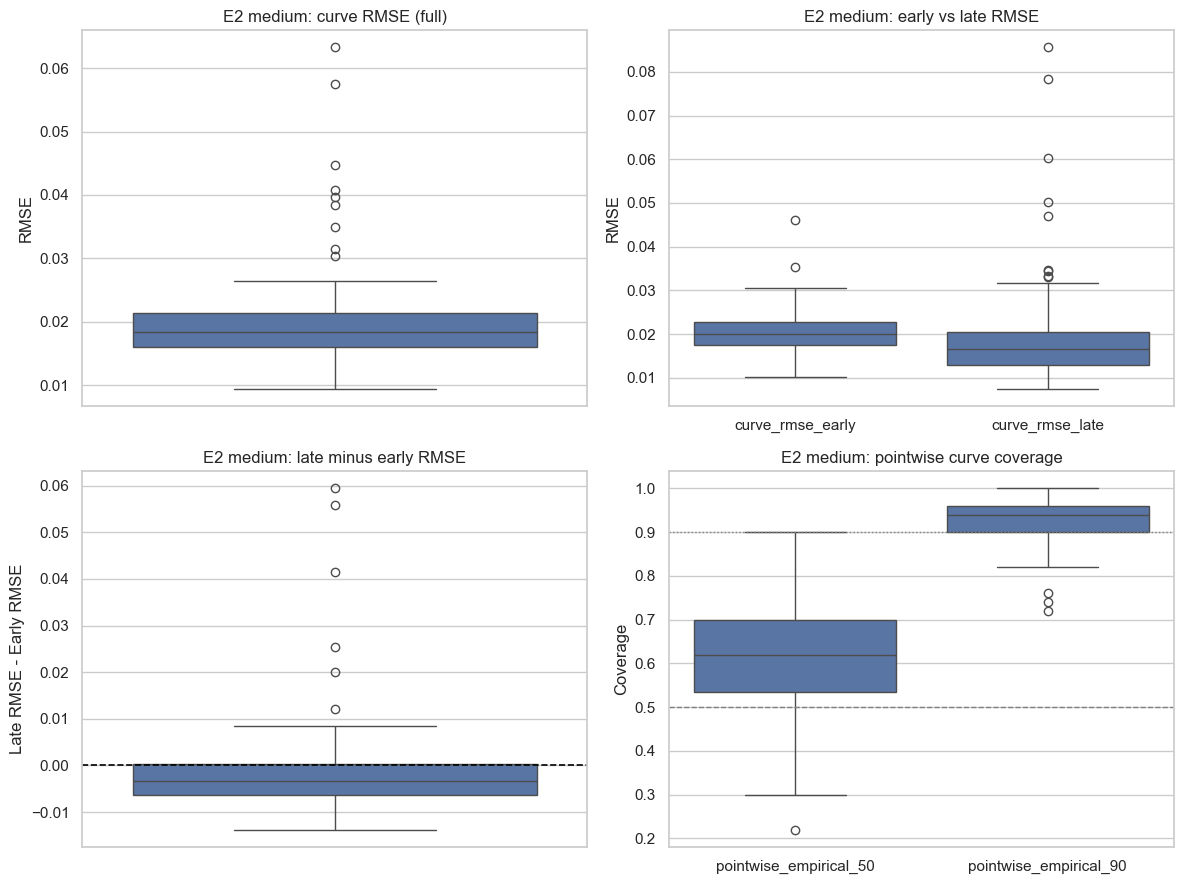

Saved:
  outputs_E2_curve_level_medium/E2_curve_case_level_medium.csv
  outputs_E2_curve_level_medium/E2_curve_summary_medium.csv
  outputs_E2_curve_level_medium/E2_curve_level_ppc_medium.png


In [44]:
curve_case_df_E2_med, curve_summary_df_E2_med = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="medium"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)

print("\nCurve-level PPC summary (E2 medium):")
display(curve_summary_df_E2_med.round(4))

print("\nCurve-level PPC case head (E2 medium):")
display(curve_case_df_E2_med.head().round(4))

plot_curve_level_ppc_summary(
    curve_case_df_E2_med,
    severity_label="medium",
    out_dir="outputs_E2_curve_level_medium",
)

os.makedirs("outputs_E2_curve_level_medium", exist_ok=True)
curve_case_df_E2_med.to_csv(
    "outputs_E2_curve_level_medium/E2_curve_case_level_medium.csv",
    index=False,
)
curve_summary_df_E2_med.to_csv(
    "outputs_E2_curve_level_medium/E2_curve_summary_medium.csv",
    index=False,
)

print("Saved:")
print("  outputs_E2_curve_level_medium/E2_curve_case_level_medium.csv")
print("  outputs_E2_curve_level_medium/E2_curve_summary_medium.csv")
print("  outputs_E2_curve_level_medium/E2_curve_level_ppc_medium.png")

Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.56batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.02batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.94batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.74batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.96batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.85batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.19batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 17.92batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 15.48batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 


Curve-level PPC summary (E2 mild):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6188,0.1295,0.6100,0.3990,0.8410
1,pointwise_empirical_90,0.9286,0.0436,0.9400,0.8400,0.9800
2,curve_bias_full,-0.0011,0.0075,-0.0036,-0.0064,0.0079
3,curve_mae_full,0.0150,0.0053,0.0141,0.0083,0.0236
4,curve_rmse_full,0.0195,0.0061,0.0186,0.0123,0.0284
5,curve_bias_early,-0.0033,0.0045,-0.0036,-0.0094,0.0067
6,curve_mae_early,0.0156,0.0036,0.0160,0.0092,0.0205
7,curve_rmse_early,0.0196,0.0039,0.0202,0.0121,0.0252
8,curve_bias_late,0.0011,0.0128,-0.0024,-0.0096,0.0213
9,curve_mae_late,0.0145,0.0090,0.0120,0.0069,0.0269



Curve-level PPC case head (E2 mild):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.88,1.00,-0.0027,0.0114,0.0148,0.0004,0.0094,0.0109,-0.0059,...,0.0070,0.0039,0.2448,0.3380,0.7243,0.2610,0.3380,17,0.9056,mild
1,1,0.40,0.86,0.0045,0.0200,0.0251,-0.0049,0.0182,0.0228,0.0139,...,0.0043,0.0037,0.3560,0.0938,3.7975,0.3843,0.0938,16,0.8919,mild
2,2,0.86,0.98,-0.0025,0.0080,0.0119,-0.0023,0.0092,0.0143,-0.0028,...,-0.0056,-0.0024,0.2680,0.4238,0.6325,0.2754,0.4238,17,0.9597,mild
3,3,0.58,0.92,-0.0036,0.0143,0.0189,-0.0084,0.0174,0.0222,0.0012,...,-0.0074,-0.0063,0.4925,0.2087,2.3604,0.5088,0.2087,20,0.9466,mild
4,4,0.82,0.98,-0.0055,0.0111,0.0146,-0.0064,0.0123,0.0169,-0.0046,...,-0.0051,-0.0025,0.1665,0.1870,0.8902,0.1825,0.1870,20,0.8532,mild


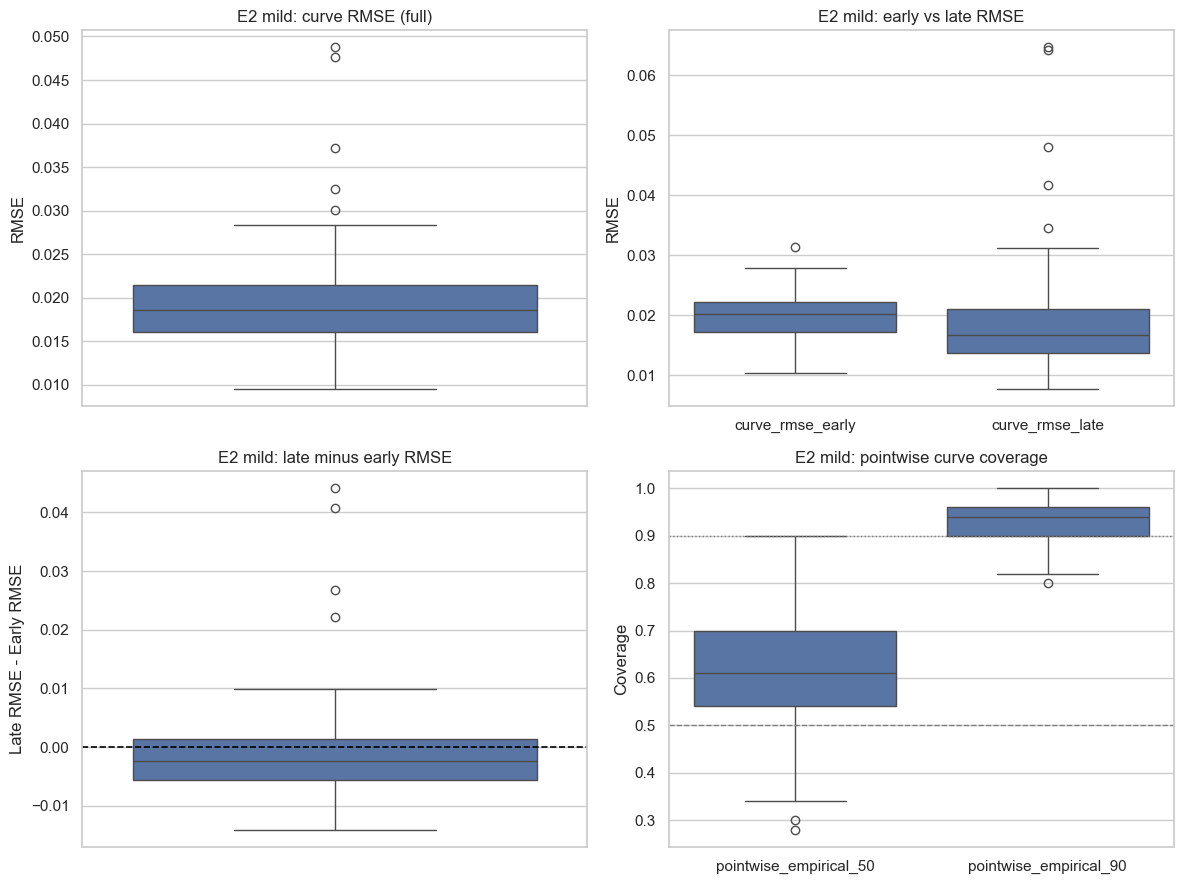

Saved:
  outputs_E2_curve_level_mild/E2_curve_case_level_mild.csv
  outputs_E2_curve_level_mild/E2_curve_summary_mild.csv
  outputs_E2_curve_level_mild/E2_curve_level_ppc_mild.png


In [52]:
curve_case_df_E2_med, curve_summary_df_E2_med = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="mild"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)

print("\nCurve-level PPC summary (E2 mild):")
display(curve_summary_df_E2_med.round(4))

print("\nCurve-level PPC case head (E2 mild):")
display(curve_case_df_E2_med.head().round(4))

plot_curve_level_ppc_summary(
    curve_case_df_E2_med,
    severity_label="mild",
    out_dir="outputs_E2_curve_level_mild",
)

os.makedirs("outputs_E2_curve_level_mild", exist_ok=True)
curve_case_df_E2_med.to_csv(
    "outputs_E2_curve_level_mild/E2_curve_case_level_mild.csv",
    index=False,
)
curve_summary_df_E2_med.to_csv(
    "outputs_E2_curve_level_mild/E2_curve_summary_mild.csv",
    index=False,
)

print("Saved:")
print("  outputs_E2_curve_level_mild/E2_curve_case_level_mild.csv")
print("  outputs_E2_curve_level_mild/E2_curve_summary_mild.csv")
print("  outputs_E2_curve_level_mild/E2_curve_level_ppc_mild.png")

Sampling: 100%|██████████| 1/1 [00:00<00:00, 16.06batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.74batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.40batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.38batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.12batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.02batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.62batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.74batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.58batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 


Curve-level PPC summary (E2 strong):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6280,0.1349,0.6200,0.3600,0.8600
1,pointwise_empirical_90,0.9142,0.0738,0.9300,0.8330,0.9800
2,curve_bias_full,-0.0015,0.0057,-0.0035,-0.0067,0.0115
3,curve_mae_full,0.0151,0.0061,0.0138,0.0083,0.0268
4,curve_rmse_full,0.0200,0.0073,0.0184,0.0123,0.0343
5,curve_bias_early,-0.0034,0.0052,-0.0039,-0.0098,0.0040
6,curve_mae_early,0.0165,0.0055,0.0163,0.0089,0.0249
7,curve_rmse_early,0.0210,0.0069,0.0201,0.0120,0.0312
8,curve_bias_late,0.0005,0.0095,-0.0020,-0.0086,0.0203
9,curve_mae_late,0.0137,0.0081,0.0112,0.0066,0.0303



Curve-level PPC case head (E2 strong):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.86,0.96,-0.0035,0.0110,0.0144,-0.0003,0.0090,0.0105,-0.0067,...,0.0071,0.0041,0.1596,0.3380,0.4722,0.2610,0.3380,17,0.4112,strong
1,1,0.36,0.64,0.0089,0.0303,0.0383,0.0060,0.0303,0.0389,0.0118,...,-0.0011,0.0001,0.2233,0.0938,2.3814,0.3843,0.0938,16,0.3839,strong
2,2,0.86,0.98,-0.0022,0.0081,0.0120,-0.0018,0.0093,0.0143,-0.0026,...,-0.0054,-0.0024,0.1880,0.4238,0.4436,0.2754,0.4238,17,0.5194,strong
3,3,0.52,0.86,-0.0037,0.0163,0.0217,-0.0110,0.0209,0.0264,0.0036,...,-0.0108,-0.0092,0.3541,0.2087,1.6969,0.5088,0.2087,20,0.4931,strong
4,4,0.80,0.98,-0.0054,0.0101,0.0139,-0.0067,0.0115,0.0165,-0.0041,...,-0.0057,-0.0027,0.1066,0.1870,0.5699,0.1825,0.1870,20,0.3064,strong


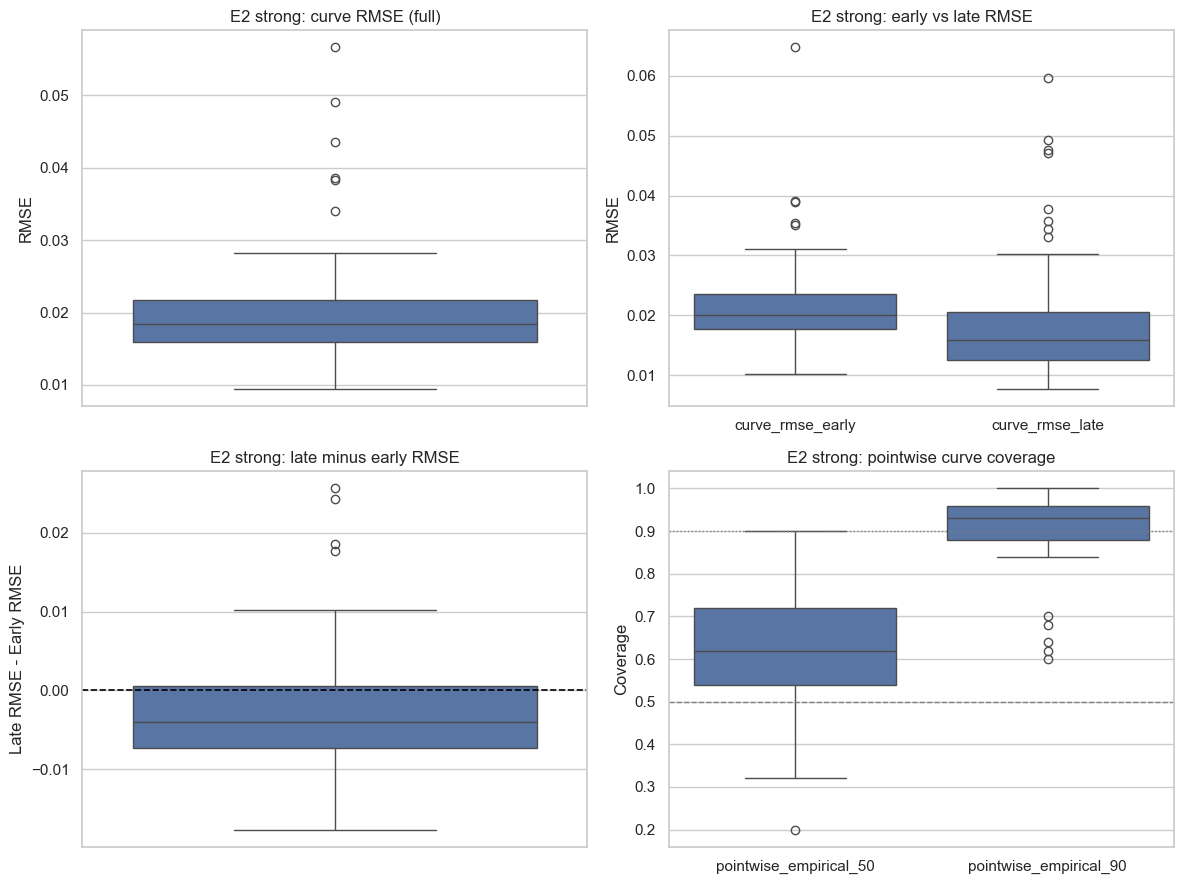

Saved:
  outputs_E2_curve_level_strong/E2_curve_case_level_strong.csv
  outputs_E2_curve_level_strong/E2_curve_summary_strong.csv
  outputs_E2_curve_level_strong/E2_curve_level_ppc_strong.png


In [53]:
curve_case_df_E2_med, curve_summary_df_E2_med = evaluate_curve_level_ppc(
    workflow=workflow_E0,
    case_simulator=lambda rng=None: simulate_case_E2(rng=rng, severity="strong"),
    predictive_curve_simulator=simulate_curve,
    n_test=100,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
    split_frac=0.5,
)

print("\nCurve-level PPC summary (E2 strong):")
display(curve_summary_df_E2_med.round(4))

print("\nCurve-level PPC case head (E2 strong):")
display(curve_case_df_E2_med.head().round(4))

plot_curve_level_ppc_summary(
    curve_case_df_E2_med,
    severity_label="strong",
    out_dir="outputs_E2_curve_level_strong",
)

os.makedirs("outputs_E2_curve_level_strong", exist_ok=True)
curve_case_df_E2_med.to_csv(
    "outputs_E2_curve_level_strong/E2_curve_case_level_strong.csv",
    index=False,
)
curve_summary_df_E2_med.to_csv(
    "outputs_E2_curve_level_strong/E2_curve_summary_strong.csv",
    index=False,
)

print("Saved:")
print("  outputs_E2_curve_level_strong/E2_curve_case_level_strong.csv")
print("  outputs_E2_curve_level_strong/E2_curve_summary_strong.csv")
print("  outputs_E2_curve_level_strong/E2_curve_level_ppc_strong.png")

The curve-level PPC results show that, across the mild, medium, and strong misspecification settings, posterior predictive curves remain comparatively close to the observed trajectories, even when parameter-level posterior calibration deteriorates sharply. This pattern is visible both in the pointwise coverage metrics and in the full-curve discrepancy measures.

First, pointwise predictive coverage remains high across all three severities. The empirical 90% pointwise coverage is 0.9286 under mild misspecification, 0.9264 under medium misspecification, and 0.9142 under strong misspecification. The corresponding empirical 50% pointwise coverage values are 0.6188, 0.6138, and 0.6280. Thus, although there is some variation across settings, there is no monotonic collapse in pointwise curve coverage analogous to what is observed for the posterior intervals of the reference quantities β and R0. If anything, pointwise predictive uncertainty remains slightly conservative across the entire severity range.

Second, the overall discrepancy between the observed curve and the posterior predictive median curve remains small in all three settings. The full-curve RMSE is 0.0195 in the mild setting, 0.0203 in the medium setting, and 0.0200 in the strong setting. Likewise, the full-curve MAE remains stable at 0.0150, 0.0156, and 0.0151, respectively. The full-curve bias stays very close to zero throughout (-0.0011, -0.0006, -0.0015). These values are numerically small and comparable to the observation-noise scale, indicating that the predictive median curve remains reasonably close to the observed time series even under stronger misspecification.

Third, the early-versus-late window comparison does not reveal a systematic worsening in the later phase. The early-window RMSE is 0.0196, 0.0202, and 0.0210 for mild, medium, and strong misspecification, while the late-window RMSE is slightly smaller in all three cases: 0.0187, 0.0194, and 0.0182. This is reflected directly in late_minus_early_rmse, which is negative throughout: -0.0009 for mild, -0.0008 for medium, and -0.0029 for strong. The same qualitative pattern appears for MAE (late_minus_early_mae = -0.0011, -0.0008, -0.0028). Therefore, under the current early/late split and median-curve comparison, the curve-level discrepancy metrics do not support the claim that misspecification produces a clear late-phase predictive breakdown.

So, the curve-level PPC results reinforce the same broader conclusion already suggested by the feature-level PPC analyses: the main misspecification signal in E2 is not a dramatic failure to reproduce the observed epidemic curves, but a severe degradation in posterior reliability for the transmission-related reference quantities. Even under strong time-varying transmission misspecification, the inference model still generates predictive curves that remain broadly plausible according to the pointwise-coverage and median-curve discrepancy diagnostics used here. This means that, in the current E2 setting, misspecification is revealed much more clearly by parameter-level bias and under-coverage than by low-dimensional predictive summaries or whole-curve fit diagnostics.